# dem4cli demo

**Part 2. Lifetime exposure**
- GMT mapping 
- lifetime exposure functions

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import regionmask
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
from math import ceil 
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
%matplotlib inline 

sys.path.append('..')
from gmt_mapping import * 
from lifetime_exposure import *
from population_demographics import * 

# 1) Load_GMT()

### 10yrmean

In [2]:
dir_temperature_trajectories

'/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/temperature-trajectories'

In [63]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrmean',
    smooth_first_decades=False
)


In [64]:
df_GMT_strj


,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,...,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5
1950,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,...,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417
1951,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,...,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391
1952,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,...,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499
1953,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,...,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225
1954,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,...,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329
2116,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329
2117,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329
2118,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329


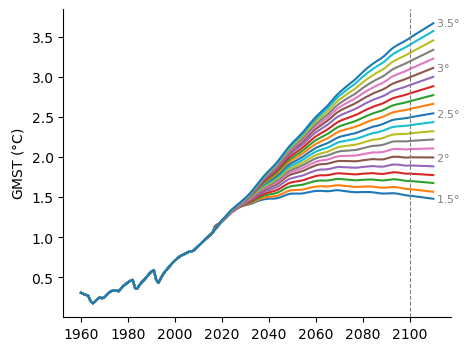

In [29]:
warminglevels = [1.5, 2, 2.5, 3, 3.5]
offsets = [-.01, 0, +.05, +.12, +.18]

fig, ax = plt.subplots(figsize=(5,4))

df_GMT_strj.loc[1960:2110].plot(ax=ax, legend=False)

ax.axvline(2100, ls='--', c='gray', lw=.8)
for lev, off in zip(warminglevels, offsets):
    ax.text(2111, lev+off, str(lev)+'$\degree$', c='gray', fontsize='8', va='center')

plt.ylabel('GMST ($\degree$C)')

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

In [65]:
df_GMT_OS.tail(20)

,1.4
2100,1.424
2101,1.424
2102,1.424
2103,1.424
2104,1.424
2105,1.424
2106,1.424
2107,1.424
2108,1.424
2109,1.424


In [66]:
df_GMT_noOS.tail(20)

,1.3
2100,1.344
2101,1.344
2102,1.344
2103,1.344
2104,1.344
2105,1.344
2106,1.344
2107,1.344
2108,1.344
2109,1.344


In [67]:
df_GMT_15.tail(20)


,1.3
2100,1.336467
2101,1.361027
2102,1.361027
2103,1.361027
2104,1.361027
2105,1.361027
2106,1.361027
2107,1.361027
2108,1.361027
2109,1.361027


In [68]:
df_GMT_20.tail(20)

,2.0
2100,1.978587
2101,1.980163
2102,1.980163
2103,1.980163
2104,1.980163
2105,1.980163
2106,1.980163
2107,1.980163
2108,1.980163
2109,1.980163


In [9]:
ds_GMT_STS

<xarray.Dataset>
Dimensions:     (time: 451, percentile: 4, scenario: 4)
Coordinates:
  * time        (time) int64 1850 1851 1852 1853 1854 ... 2297 2298 2299 2300
  * percentile  (percentile) object '50.0' '95.0' '98.0' '99.0'
  * scenario    (scenario) object 'ModAct' 'Ren' 'LD' 'SP'
Data variables:
    tas         (time, percentile, scenario) float64 ...
Attributes:
    Description:  Trajectories of Global Surface Air Temperature for the Stre...
    Model:        FaIRv1.6.4
    Method:       These scenarios were originally designed for the project PR...
    region:       World
    contact:      Yann Quilcaille <yann.quilcaille@env.ethz.ch>

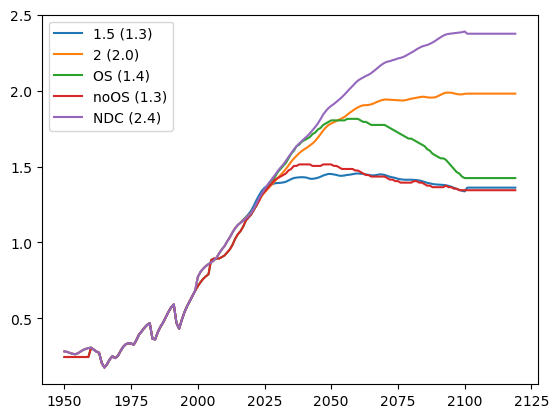

In [10]:
fig, ax = plt.subplots()
labels=['1.5','2','OS', 'noOS', 'NDC']

for i,df in enumerate([df_GMT_15, df_GMT_20,  df_GMT_OS, df_GMT_noOS,df_GMT_NDC ]): #
    df.plot(ax=ax)
    labels[i] = labels[i]+' ('+df.columns.values[0]+')'

ax.legend(labels, loc='upper left')


# issues: 
# 3) other extension methods dont work properly I think.. 

# questions
# how is NDC chosen/set
# how different are the 1.5/2 deg scenariosa nd the strj and how are they made/selected
# how were OS and noOS selected


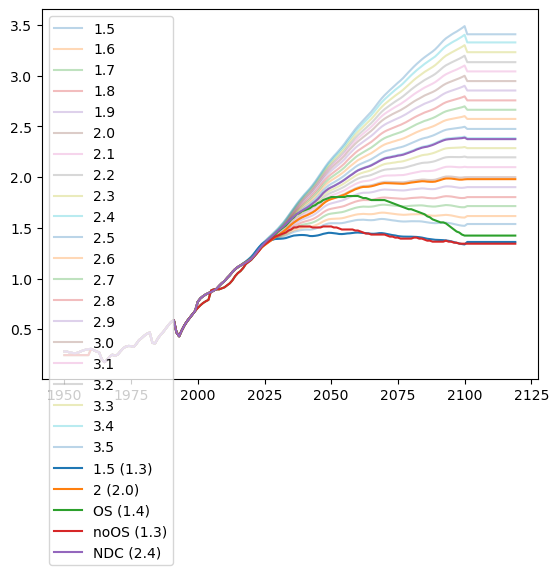

In [11]:
fig, ax = plt.subplots()

df_GMT_strj.plot(ax=ax, alpha=.3)

labels=['1.5','2','OS', 'noOS', 'NDC']

ax.set_prop_cycle(None) 

for i,df in enumerate([df_GMT_15, df_GMT_20,  df_GMT_OS, df_GMT_noOS,df_GMT_NDC ]): 
    labels[i] = labels[i]+' ('+df.columns.values[0]+')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')


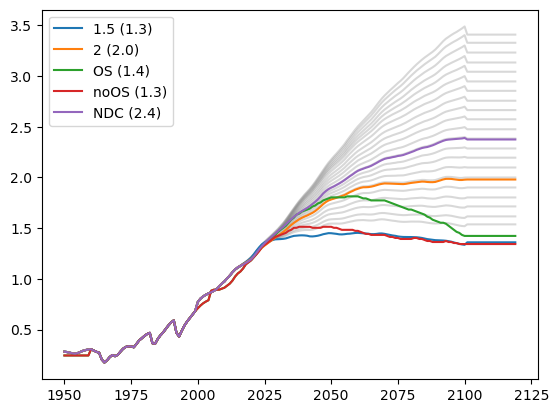

In [12]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

### 10yrtrend

In [13]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=False
)

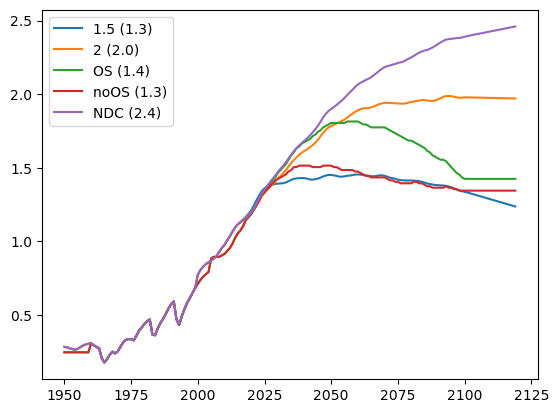

In [14]:
fig, ax = plt.subplots()
labels=['1.5','2','OS', 'noOS', 'NDC']

for i,df in enumerate([df_GMT_15, df_GMT_20,  df_GMT_OS, df_GMT_noOS,df_GMT_NDC ]): #
    df.plot(ax=ax)
    labels[i] = labels[i]+' ('+df.columns.values[0]+')'

ax.legend(labels, loc='upper left')

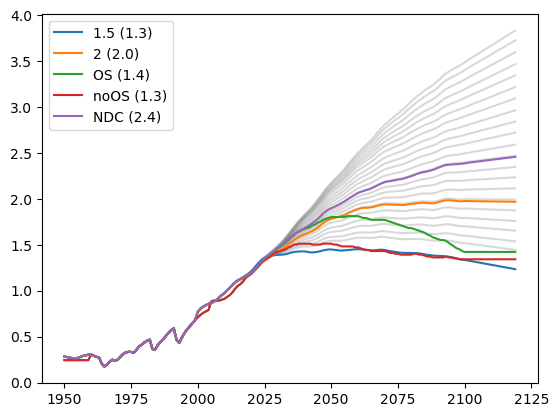

In [15]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

In [16]:
## test different extensions

In [17]:

def extend_gmt_to_year_range(df, year_start=1950, year_end=2119, gmt_extend_method=None):
    """
    Extend a GMT time series (Series or DataFrame) to a given year range.
    
    Handles both backward and forward extension using specified method.
    
    Parameters
    ----------
    df : pd.Series or pd.DataFrame
        Input data indexed by year.
    year_start : int, optional
        Earliest year to extend to (fills backward if needed).
    year_end : int, optional
        Latest year to extend to (fills forward if needed).
    gmt_extend_method : {'10yrmean', 'lastyear', '10yrtrend'}, optional
        Method for forward extension beyond the last available year.
    
    Returns
    -------
    pd.DataFrame
        Extended dataset over [year_start, year_end].
    """
    # --- Ensure DataFrame ---
    if isinstance(df, pd.Series):
        df = df.to_frame()
        df.columns = [f"{df.loc[2100].values[0]:.1f}"] if 2100 in df.index else ["value"] # [str(round(df.loc[2100].values[0], 2))] if 2100 in df.index else ["value"]

    df = df.copy()
    df.index = df.index.astype(int)
    
    min_year, max_year = int(np.nanmin(df.index)), int(np.nanmax(df.index))

    # --- Backward extension ---
    if year_start is not None and min_year > year_start:
        first_10y_mean = df.iloc[:10, :].mean()
        for year in range(year_start, min_year):
            df.loc[year] = first_10y_mean
    
    df = df.sort_index()

    # --- Forward extension ---
    if year_end is not None and max_year < year_end:
        if gmt_extend_method == "10yrmean":
            last_10y_mean = df.iloc[-10:, :].mean()
            for year in range(max_year + 1, year_end + 1):
                df.loc[year] = last_10y_mean

        elif gmt_extend_method == "lastyear":
            last_year_vals = df.iloc[-1, :]
            for year in range(max_year + 1, year_end + 1):
                df.loc[year] = last_year_vals

        elif gmt_extend_method == "10yrtrend":
            yrs = np.arange(max_year - 9, max_year + 1)
            trends = {col: np.polyfit(yrs, df.loc[yrs, col].astype(float), 1) for col in df.columns}
            for year in range(max_year + 1, year_end + 1):
                df.loc[year] = {col: np.polyval(trends[col], year) for col in df.columns}

    # --- Sort index and restrict range ---
    df = df.sort_index()
    if year_start is not None or year_end is not None:
        df = df.loc[
            (df.index >= (year_start if year_start is not None else df.index.min())) &
            (df.index <= (year_end if year_end is not None else df.index.max()))
        ]

    return df

In [18]:
from scipy.io import loadmat

# Load GMT_OS
mat_data = loadmat(dir_temperature_trajectories + '/temperature-trajectories_Wim/GMT_OS.mat', squeeze_me=True)
GMT_OS = mat_data['GMT_OS'].flatten()
years = np.arange(1960, 1960 + len(GMT_OS))
df_GMT_OS = pd.Series(GMT_OS, index=years)
df_GMT_OS.name = None
df_GMT_OS.index.name = None

# Load GMT_noOS
mat_data = loadmat(dir_temperature_trajectories + '/temperature-trajectories_Wim/GMT_noOS.mat', squeeze_me=True)
GMT_noOS = mat_data['GMT_noOS'].flatten()
years = np.arange(1960, 1960 + len(GMT_noOS))
df_GMT_noOS = pd.Series(GMT_noOS, index=years)
df_GMT_noOS.name = None
df_GMT_noOS.index.name = None



In [19]:
df_GMT_OS

1960    0.306832
1961    0.293686
1962    0.281428
1963    0.273481
1964    0.206345
          ...   
2109    1.439000
2110    1.439000
2111    1.439000
2112    1.439000
2113    1.439000
Length: 154, dtype: float64

<Axes: >

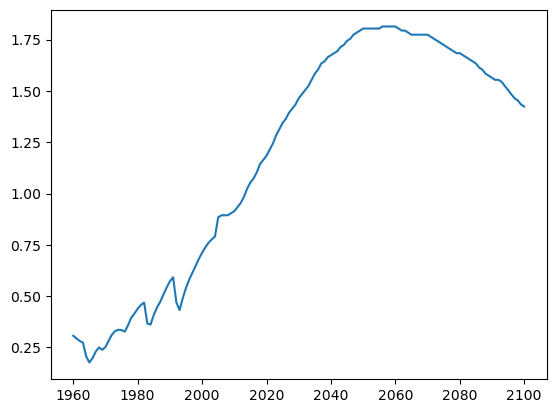

In [20]:
df_GMT_OS.loc[:2100].plot() # try extending OS with trend - too much no?

In [21]:
df_GMT_OS = extend_gmt_to_year_range(df_GMT_OS.loc[:2100],1950, 2119, gmt_extend_method='lastyear')
df_GMT_noOS = extend_gmt_to_year_range(df_GMT_noOS.loc[:2100],1950,2119, gmt_extend_method='lastyear')

<Axes: >

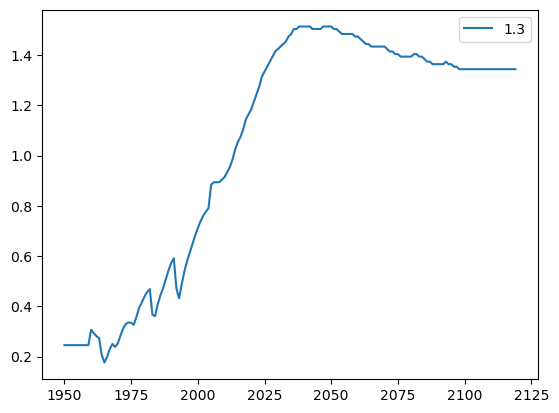

In [22]:
df_GMT_noOS.plot()

<Axes: >

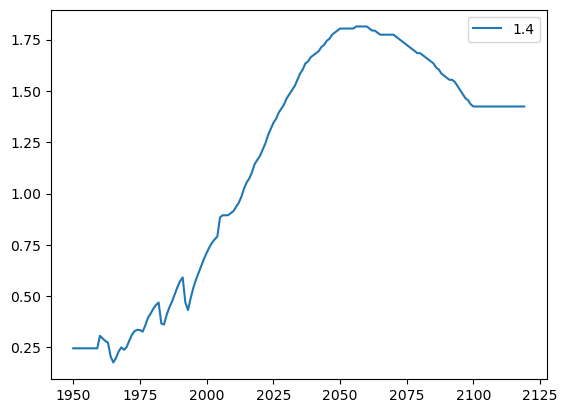

In [23]:
df_GMT_OS.plot()

In [24]:
year_start=1950

# collect new ar6 scens from IASA explorer
df_GMT_ar6 = pd.read_csv(dir_temperature_trajectories+'/temperature-trajectories_AR6/ar6_c1_c7_nogaps_2000-2100.csv',header=0)
df_GMT_ar6.loc[:,'Model'] = df_GMT_ar6.loc[:,'Model']+'_'+df_GMT_ar6.loc[:,'Scenario']
df_GMT_ar6 = df_GMT_ar6.drop(columns=['Scenario','Region','Variable','Unit']).transpose()
df_GMT_ar6.columns=df_GMT_ar6.loc['Model',:]
df_GMT_ar6.columns.name = None
df_GMT_ar6 = df_GMT_ar6.drop(df_GMT_ar6.index[0])
df_GMT_ar6 = df_GMT_ar6.dropna(axis=1)
df_GMT_ar6.index = df_GMT_ar6.index.astype(int)
df_hist_all = df_GMT_15.loc[year_start:1999]
df_hist_all = pd.concat([df_hist_all for i in range(len(df_GMT_ar6.columns))],axis=1)
df_hist_all.columns = df_GMT_ar6.columns
df_GMT_ar6 = pd.concat([df_hist_all,df_GMT_ar6],axis=0) # add historical values to additional scenarios

# drop dups
df_GMT_ar6 = df_GMT_ar6[~df_GMT_ar6.index.duplicated(keep='first')]

# get new trajects - this overwrites the above df_GMT_15
df_GMT_lb, df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_30, df_GMT_40 = ar6_scen_grab(
    scen_thresholds,
    df_GMT_ar6,
)  

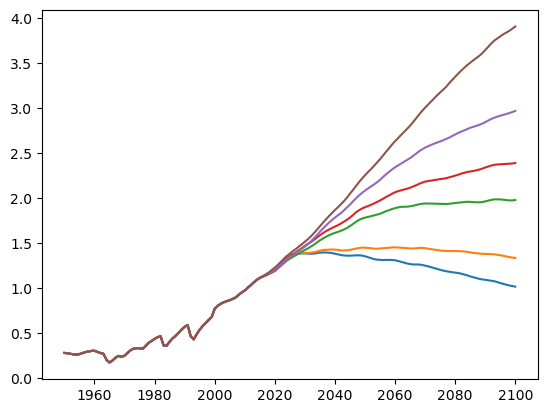

In [25]:
fig, ax = plt.subplots()

for df in [df_GMT_lb, df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_30, df_GMT_40]:
    df.plot()

# ar6_scen_grab takes lowest highest and some in the middle, then later interpolates between all of these to have regularly spaced at 0.1 deg intervals in 2100

<Axes: >

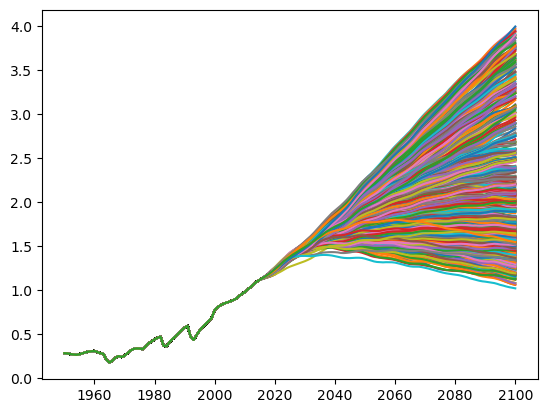

In [26]:
df_GMT_ar6.plot(legend=False)

# all the input scenarios, with one pathway until 1999 

# 2) Load_ISIMIP

Develop how to load data and GMT-mapping metadata

## 2a. Load models : test start

In [27]:

GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585']

extremes="FWI95d" # e.g. "FWI95d"
model_names = GCMs
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI' # structure should be climatedata_dir/scenario/model
scenarios = scenarios

smoothing=True
rolling_window=21

model_gmst_dir = None # need this!! and prep the GMST 

gmt_mapping_method = 'year-to-year' 

In [28]:
extreme = extremes
model=model_names[0]
scenario=scenarios[1]

In [29]:
scenario

'ssp126'

In [30]:
# initialise counter, metadata dictionary, pic list, pic meta, and 
i = 1
d_climate_data_meta = {}

In [31]:
filepath = glob.glob(os.path.join(climatedata_dir, scenario, model, f'*{model}*{extreme}.nc'))[0]
print(f'Loading {filepath}')

# load data: annual count of exceedances of threshold (already preprocessed)
da_rcp = xr.open_dataarray(filepath, chunks='auto')

# save metadata
d_climate_data_meta[i] = {
    'extreme': extreme,
    'model': model,
    'scenario': scenario,
}

#load associated historical variable
filepath = glob.glob(os.path.join(climatedata_dir, 'historical', model, f'*{model}*{extreme}.nc'))[0]
print(f'Loading {filepath}')
da_hist = xr.open_dataarray(filepath, chunks='auto')

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc


In [32]:
da_exceedances = xr.concat([da_hist,da_rcp], dim='time')


In [33]:
da_exceedances

<xarray.DataArray 'FWI95d' (time: 151, latitude: 392, longitude: 500)>
dask.array<concatenate, shape=(151, 392, 500), dtype=int64, chunksize=(85, 392, 500), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float64 -14.96 -14.86 -14.76 ... 34.74 34.84 34.94
  * latitude   (latitude) float64 71.09 70.99 70.89 70.79 ... 32.19 32.09 31.99
    quantile   float64 0.95
  * time       (time) datetime64[ns] 1950-12-31 1951-12-31 ... 2100-12-31

## 2b. GMT per simulation

In [45]:
filepath_model_gmst='../data/gmst-models/gmst_models_1850_2100_fwi.csv'
df_GMT = pd.read_csv(filepath_model_gmst,index_col=0)
df_GMT['year'] = df_GMT['year'].astype(int)


In [46]:
df_GMT

,year,experiment_id,source_id,tas
0,1850,historical,ACCESS-CM2,287.007494
1,1850,historical,CNRM-ESM2-1,286.900465
2,1850,historical,CanESM5,286.806542
3,1850,historical,EC-Earth3,287.029662
4,1850,historical,MPI-ESM1-2-HR,287.064616
...,...,...,...,...
7525,2100,ssp585,CNRM-ESM2-1,292.475368
7526,2100,ssp585,CanESM5,294.452385
7527,2100,ssp585,EC-Earth3,293.272894
7528,2100,ssp585,MPI-ESM1-2-HR,291.375668


In [47]:
df_wide = df_GMT.pivot_table(
    index=["year", "experiment_id"],
    columns="source_id",
    values="tas"
)
df_wide

source_id           ACCESS-CM2  CNRM-ESM2-1     CanESM5   EC-Earth3  \
year experiment_id                                                    
1850 historical     287.007494   286.900465  286.806542  287.029662   
1851 historical     287.016985   287.081066  286.551052  287.130825   
1852 historical     287.174542   287.005218  286.622251  287.183553   
1853 historical     287.070948   286.872643  286.776655  287.000297   
1854 historical     287.141159   286.873972  286.638360  286.945980   
...                        ...          ...         ...         ...   
2099 ssp585         293.114663   292.592435  294.441621  293.299713   
2100 ssp126         289.419884   288.991151  289.683514  289.268752   
     ssp245         290.470334   290.101415  291.057557  290.430415   
     ssp370         291.928374   291.379378  293.137034  291.863306   
     ssp585         293.145303   292.475368  294.452385  293.272894   

source_id           MPI-ESM1-2-HR  MRI-ESM2-0  
year experiment_id                             
1850 historical        287.064616  286.939424  
1851 historical        287.088070  286.991131  
1852 historical        287.281398  286.910700  
1853 historical        287.388171  286.805766  
1854 historical        287.093118  286.766465  
...                           ...         ...  
2099 ssp585            291.458242  291.567732  
2100 ssp126            288.668542  288.494456  
     ssp245            289.534073  289.579336  
     ssp370            290.874307  290.906602  
     ssp585            291.375668  291.848270  

[509 rows x 6 columns]

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker

filepath_model_gmst='../data/gmst-models/gmst_models_1850_2100_fwi.csv'
df_GMT = pd.read_csv(filepath_model_gmst,index_col=0)
df_GMT['year'] = df_GMT['year'].astype(int)

# --- 1. Compute baseline (1850–1900 mean for each model) ---
baseline = (
    df_GMT.query("1850 <= year <= 1900")
    .groupby("source_id")["tas"]
    .mean()
    .rename("tas_baseline")
)
df_GMT = df_GMT.merge(baseline, on="source_id")
df_GMT["tas_anom"] = df_GMT["tas"] - df_GMT["tas_baseline"]

# --- 2. Pivot to wide format ---
df_wide = df_GMT.pivot_table(
    index=["year", "experiment_id"],
    columns="source_id",
    values="tas_anom"
)


In [49]:
baseline - 273.15 # avg T in 1850-1900


source_id
ACCESS-CM2       13.754873
CNRM-ESM2-1      13.658067
CanESM5          13.563354
EC-Earth3        13.962913
MPI-ESM1-2-HR    13.924616
MRI-ESM2-0       13.731488
Name: tas_baseline, dtype: float64

In [50]:
df_wide

source_id           ACCESS-CM2  CNRM-ESM2-1   CanESM5  EC-Earth3  \
year experiment_id                                                 
1850 historical       0.102621     0.092399  0.093188  -0.083251   
1851 historical       0.112112     0.272999 -0.162302   0.017912   
1852 historical       0.269669     0.197152 -0.091103   0.070640   
1853 historical       0.166075     0.064576  0.063301  -0.112616   
1854 historical       0.236286     0.065905 -0.074994  -0.166933   
...                        ...          ...       ...        ...   
2099 ssp585           6.209790     5.784368  7.728267   6.186800   
2100 ssp126           2.515011     2.183085  2.970160   2.155840   
     ssp245           3.565461     3.293349  4.344203   3.317502   
     ssp370           5.023501     4.571312  6.423680   4.750394   
     ssp585           6.240430     5.667301  7.739031   6.159981   

source_id           MPI-ESM1-2-HR  MRI-ESM2-0  
year experiment_id                             
1850 historical         -0.010000    0.057936  
1851 historical          0.013454    0.109643  
1852 historical          0.206782    0.029212  
1853 historical          0.313555   -0.075722  
1854 historical          0.018502   -0.115023  
...                           ...         ...  
2099 ssp585              4.383627    4.686244  
2100 ssp126              1.593926    1.612968  
     ssp245              2.459458    2.697849  
     ssp370              3.799691    4.025114  
     ssp585              4.301053    4.966782  

[509 rows x 6 columns]

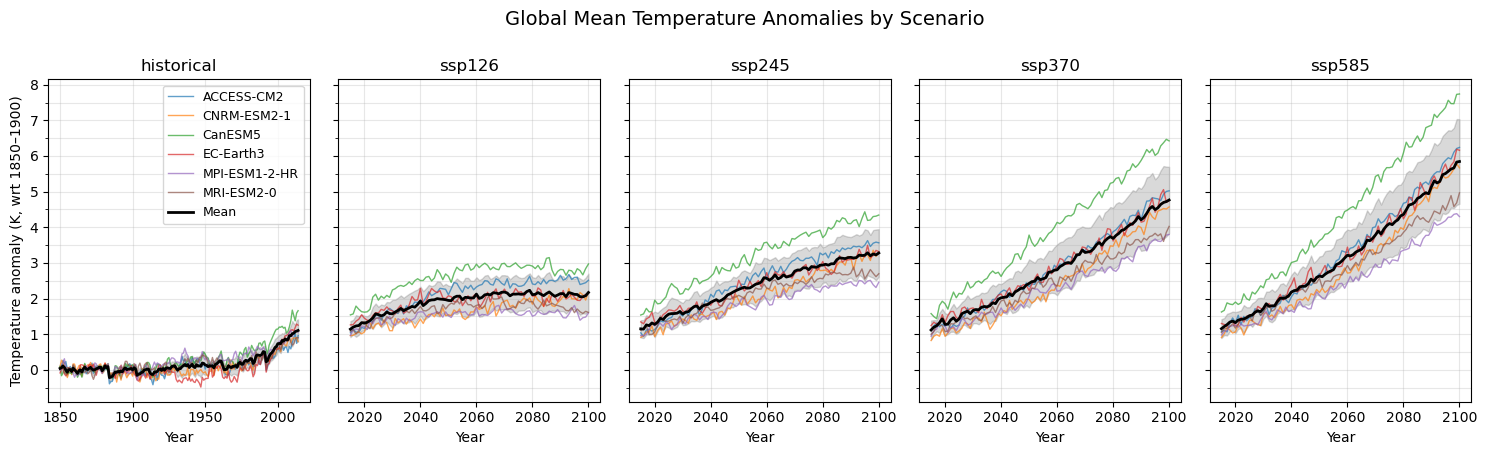

In [51]:

# --- 3. Plot setup ---
scenarios = df_wide.index.get_level_values("experiment_id").unique()
n_scenarios = len(scenarios)

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_scenarios,
    figsize=(3 * n_scenarios, 4.5),
    sharey=True
)

if n_scenarios == 1:
    axes = [axes]

# --- 4. Plot each scenario ---
for ax, scenario in zip(axes, scenarios):
    df_scenario = df_wide.xs(scenario, level="experiment_id")

    # Plot individual model lines
    for model in df_scenario.columns:
        ax.plot(df_scenario.index, df_scenario[model], lw=1, alpha=0.7, label=model)

    # Ensemble mean and ±1σ
    mean = df_scenario.mean(axis=1)
    std = df_scenario.std(axis=1)
    ax.plot(df_scenario.index, mean, color="black", lw=2, label="Mean")
    ax.fill_between(df_scenario.index, mean - std, mean + std, color="black", alpha=0.15)

    ax.set_title(scenario)
    ax.set_xlabel("Year")
    ax.grid(True, alpha=0.3)
    ax.grid(True, which='minor', alpha=0.3)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))

axes[0].set_ylabel("Temperature anomaly (K, wrt 1850–1900)")
axes[0].legend(bbox_to_anchor=(1,1), fontsize=9)
fig.suptitle("Global Mean Temperature Anomalies by Scenario", fontsize=14, y=1)
plt.tight_layout()
plt.show()


In [52]:
gmt_anomaly_baseline_period = (1850,1900)
gmt_anomaly_correction = 0 
modelname=GCMs[0]
scenario=scenarios[2]

# simpler for the code 
df_GMT = pd.read_csv(filepath_model_gmst,index_col=0)
df_GMT['year'] = df_GMT['year'].astype(int)
modelname = model if model != 'EC-EARTH' else 'EC-Earth3'
df_GMT_hist = df_GMT[(df_GMT['experiment_id']=='historical') & (df_GMT['source_id']==modelname)].set_index('year').drop(columns=['experiment_id','source_id']).dropna()
df_GMT_rcp = df_GMT[(df_GMT['experiment_id']==scenario) & (df_GMT['source_id']==modelname)].set_index('year').drop(columns=['experiment_id','source_id']).dropna()

# concatenate historical and future GMT data
df_GMT = pd.concat([df_GMT_hist,df_GMT_rcp])

# convert GMT from absolute values to anomalies - if you use a non 1850-1900 period should provide a gmt_anomaly_correction
df_GMT = df_GMT - df_GMT.loc[gmt_anomaly_baseline_period[0] : gmt_anomaly_baseline_period[1]].mean() + gmt_anomaly_correction



In [53]:
df_GMT

,tas
year,
1850,0.057936
1851,0.109643
1852,0.029212
1853,-0.075722
1854,-0.115023
...,...
2096,2.677123
2097,2.816019
2098,2.710975


### GMT anomaly correction: compare with obs GMT

To make the timeseries relative to 1985-2014 warming level 

In [54]:


filepath_gmt_obs = '../data/gmst-obs/GCH_time_series_of_annual_global_temperatures_1850-2024_wrt_1991-2020.csv'

gmt_obs = pd.read_csv(filepath_gmt_obs,skiprows=3,index_col=0, na_values=-999,usecols=[0,1,2,3,4,5])

gmt_obs

,ERA5,JRA-3Q,Berkeley Earth,GISTEMP,HadCRUT5
Year,,,,,
1850,NaN,NaN,-0.084,NaN,-0.084
1851,NaN,NaN,0.014,NaN,0.107
1852,NaN,NaN,0.052,NaN,0.104
1853,NaN,NaN,0.035,NaN,0.071
1854,NaN,NaN,0.016,NaN,0.052
...,...,...,...,...,...
2020,1.310,1.263,1.261,1.274,1.258
2021,1.155,1.082,1.112,1.116,1.099
2022,1.181,1.146,1.148,1.161,1.138


<Axes: xlabel='Year'>

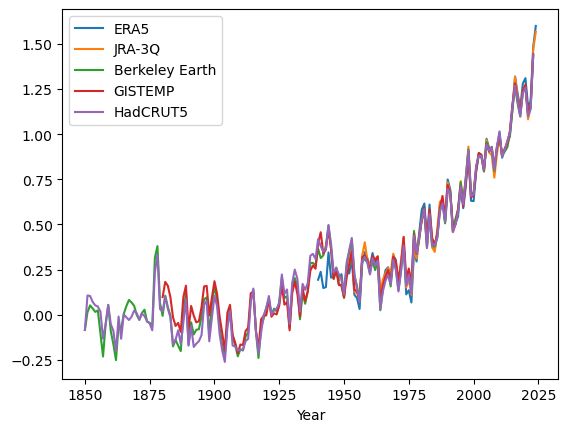

In [55]:
gmt_obs.plot()

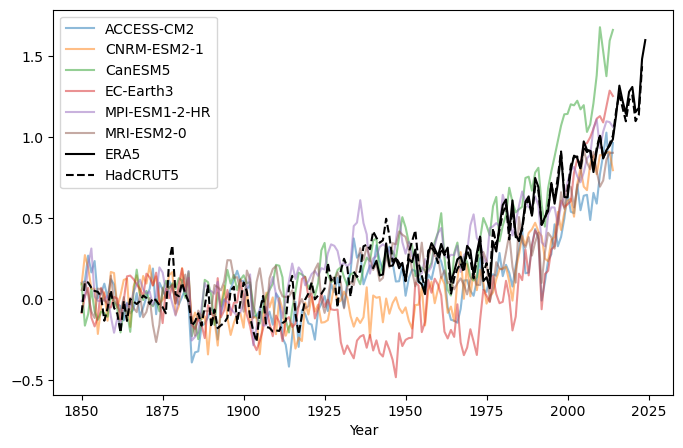

In [56]:
fig,ax = plt.subplots(figsize=(8,5))

df_scenario = df_wide.xs('historical', level="experiment_id")
df_scenario.plot(ax=ax, alpha=.5)

gmt_obs['ERA5'].plot(ax=ax, c='k')
gmt_obs['HadCRUT5'].plot(ax=ax, c='k', ls='--')

plt.legend()

### do it all relative to 1985-2014 !

In [57]:
gmt_obs[['ERA5']].loc[1985:2014].mean()[0]

0.7432

In [58]:
gmt_obs.loc[1985:2014].mean()

ERA5              0.743200
JRA-3Q            0.748733
Berkeley Earth    0.747667
GISTEMP           0.749267
HadCRUT5          0.746967
dtype: float64

In [59]:
gmt_obs.loc[1850:1900].mean()

ERA5                   NaN
JRA-3Q                 NaN
Berkeley Earth   -0.013039
GISTEMP           0.052286
HadCRUT5         -0.020608
dtype: float64

In [60]:
scenarios[2]

'ssp245'

In [61]:
df_scenario = pd.concat([df_wide.xs('historical', level="experiment_id"), df_wide.xs(scenarios[2], level="experiment_id")])
df_scenario

source_id,ACCESS-CM2,CNRM-ESM2-1,CanESM5,EC-Earth3,MPI-ESM1-2-HR,MRI-ESM2-0
year,,,,,,
1850,0.102621,0.092399,0.093188,-0.083251,-0.010000,0.057936
1851,0.112112,0.272999,-0.162302,0.017912,0.013454,0.109643
1852,0.269669,0.197152,-0.091103,0.070640,0.206782,0.029212
1853,0.166075,0.064576,0.063301,-0.112616,0.313555,-0.075722
1854,0.236286,0.065905,-0.074994,-0.166933,0.018502,-0.115023
...,...,...,...,...,...,...
2096,3.628022,3.230348,4.193259,3.495573,2.491945,2.677123
2097,3.461565,3.070280,4.205110,3.143452,2.512813,2.816019
2098,3.554259,3.356660,4.302070,3.208572,2.389425,2.710975


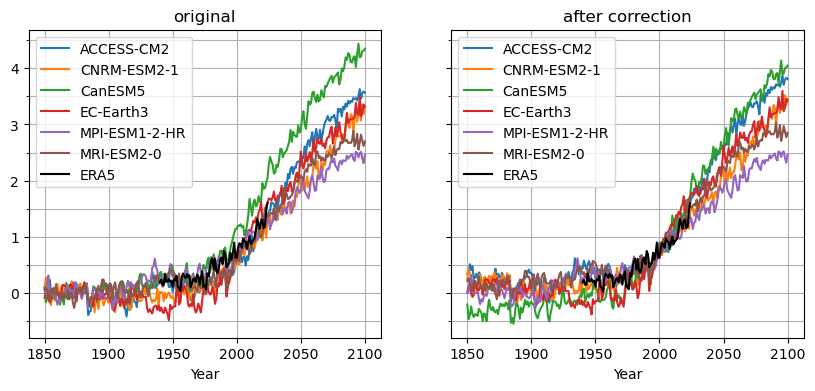

In [62]:
gmt_anomaly_baseline_period = (1985,2014)
gmt_anomaly_correction = 0.74

fig,axes=plt.subplots(1,2,figsize=(10,4), sharey=True)

# original 
df_scenario.plot(ax=axes[0])
axes[0].set_title('original')
# corrected
(df_scenario - df_scenario.loc[1985:2014].mean() + gmt_anomaly_correction).plot(ax=axes[1])
axes[1].set_title('after correction')


for ax in axes:
    gmt_obs['ERA5'].plot(ax=ax, c='k')
    #gmt_obs['HadCRUT5'].plot(ax=ax, c='k', ls='--')
    ax.grid()
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))
    ax.grid(True, which='minor')
    ax.legend()



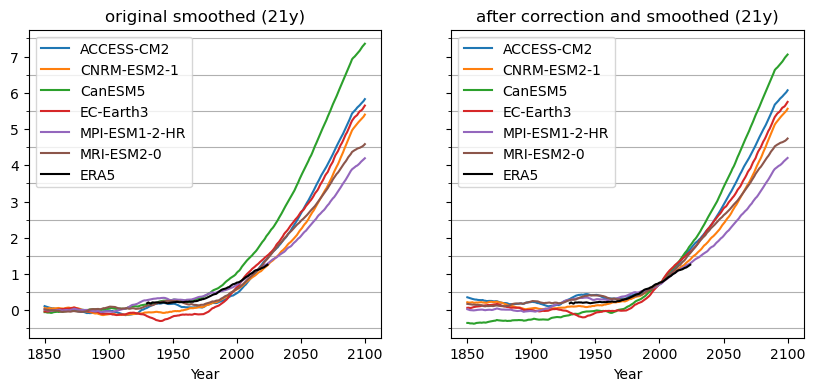

In [72]:
gmt_anomaly_baseline_period = (1985,2014)
gmt_anomaly_correction = 0.74

fig,axes=plt.subplots(1,2,figsize=(10,4), sharey=True)

# original 
df_scenario.rolling(21,min_periods=1,center=True).mean().plot(ax=axes[0])
axes[0].set_title('original smoothed (21y)')
# corrected
(df_scenario - df_scenario.loc[1985:2014].mean() + gmt_anomaly_correction).rolling(21,min_periods=1,center=True).mean().plot(ax=axes[1])
axes[1].set_title('after correction and smoothed (21y)')

for ax in axes:
    ax.grid()
    gmt_obs['ERA5'].rolling(21,min_periods=1,center=True).mean().plot(ax=ax, c='k')
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))
    ax.grid(True, which='minor')
    ax.legend()

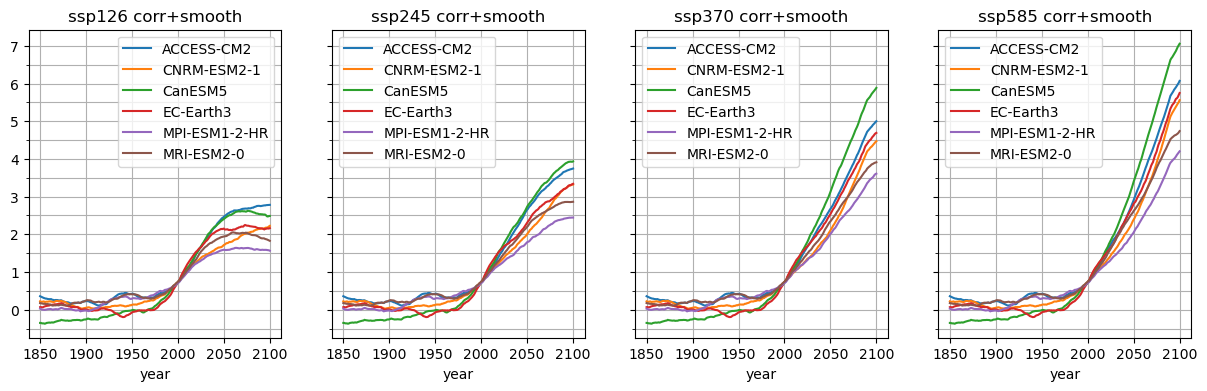

In [71]:
gmt_anomaly_baseline_period = (1985,2014)
gmt_anomaly_correction = 0.74

fig,axes=plt.subplots(1,4,figsize=(15,4), sharey=True)

for ax, scenario in zip(axes, scenarios[1:]):
    df_scenario = pd.concat([df_wide.xs('historical', level="experiment_id"), df_wide.xs(scenario, level="experiment_id")])
    (df_scenario - df_scenario.loc[1985:2014].mean() + gmt_anomaly_correction).rolling(21,min_periods=1,center=True).mean().plot(ax=ax)
    ax.set_title(f'{scenario} corr+smooth')

for ax in axes:
    ax.grid()
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))
    ax.grid(True, which='minor')
    ax.legend()


## 2c. Test open model

In [53]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']


In [54]:
d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs[0:2],                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = None,
    GMT_extra_trajectories_names = None,
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=11,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for FWI95d
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp245/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp370/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_A

## 2d. test with all scnearios

In [17]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=False
)

In [18]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']

In [19]:
d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs,                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS],
    GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS'],
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=1,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for FWI95d
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp245/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp370/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_A

In [57]:
d_climate_data_meta[1]

{'extreme': 'FWI95d',
 'model': 'ACCESS-CM2',
 'scenario': 'ssp126',
 'GMT':            tas
 1950  0.385547
 1951  0.393164
 1952  0.393677
 1953  0.379471
 1954  0.362028
 ...        ...
 2115  2.769605
 2116  2.769605
 2117  2.769605
 2118  2.769605
 2119  2.769605
 
 [170 rows x 1 columns],
 'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
 'GMT_strj_valid': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]),
 'ind_RCP2GMT_strj': array([[ 23,  23,  23, ...,  23,  23,  23],
        [ 23,  23,  23, ...,  23,  23,  23],
        [ 23,  23,  23, ...,  23,  23,  23],
        ...,
        [ 69,  72,  75, ..., 149, 149, 149],
        [ 69,  71,  75, ..., 149, 149, 149],
        [ 69,  71,  75, ..., 149, 149, 149]]),
 'GMT_15_maxdiff': 0.14355040795676718,
 'GMT_15_valid': True,
 'ind_RCP2GMT_15': array([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
        23, 23, 23, 23, 23, 23, 20, 19, 19, 21,  4, 27, 29,

### plot GMT mapping (reindexing)

Notes
- looks very similar for window of smoothig of 21 years, regardless of min_periods - check this with Amaury he was saying it was very sensitive
- check if endyears get lost with smoothing???
- ssp126 looks terrible mapped onto warm scenarios 
    - make tolerance more stringent? > no effect

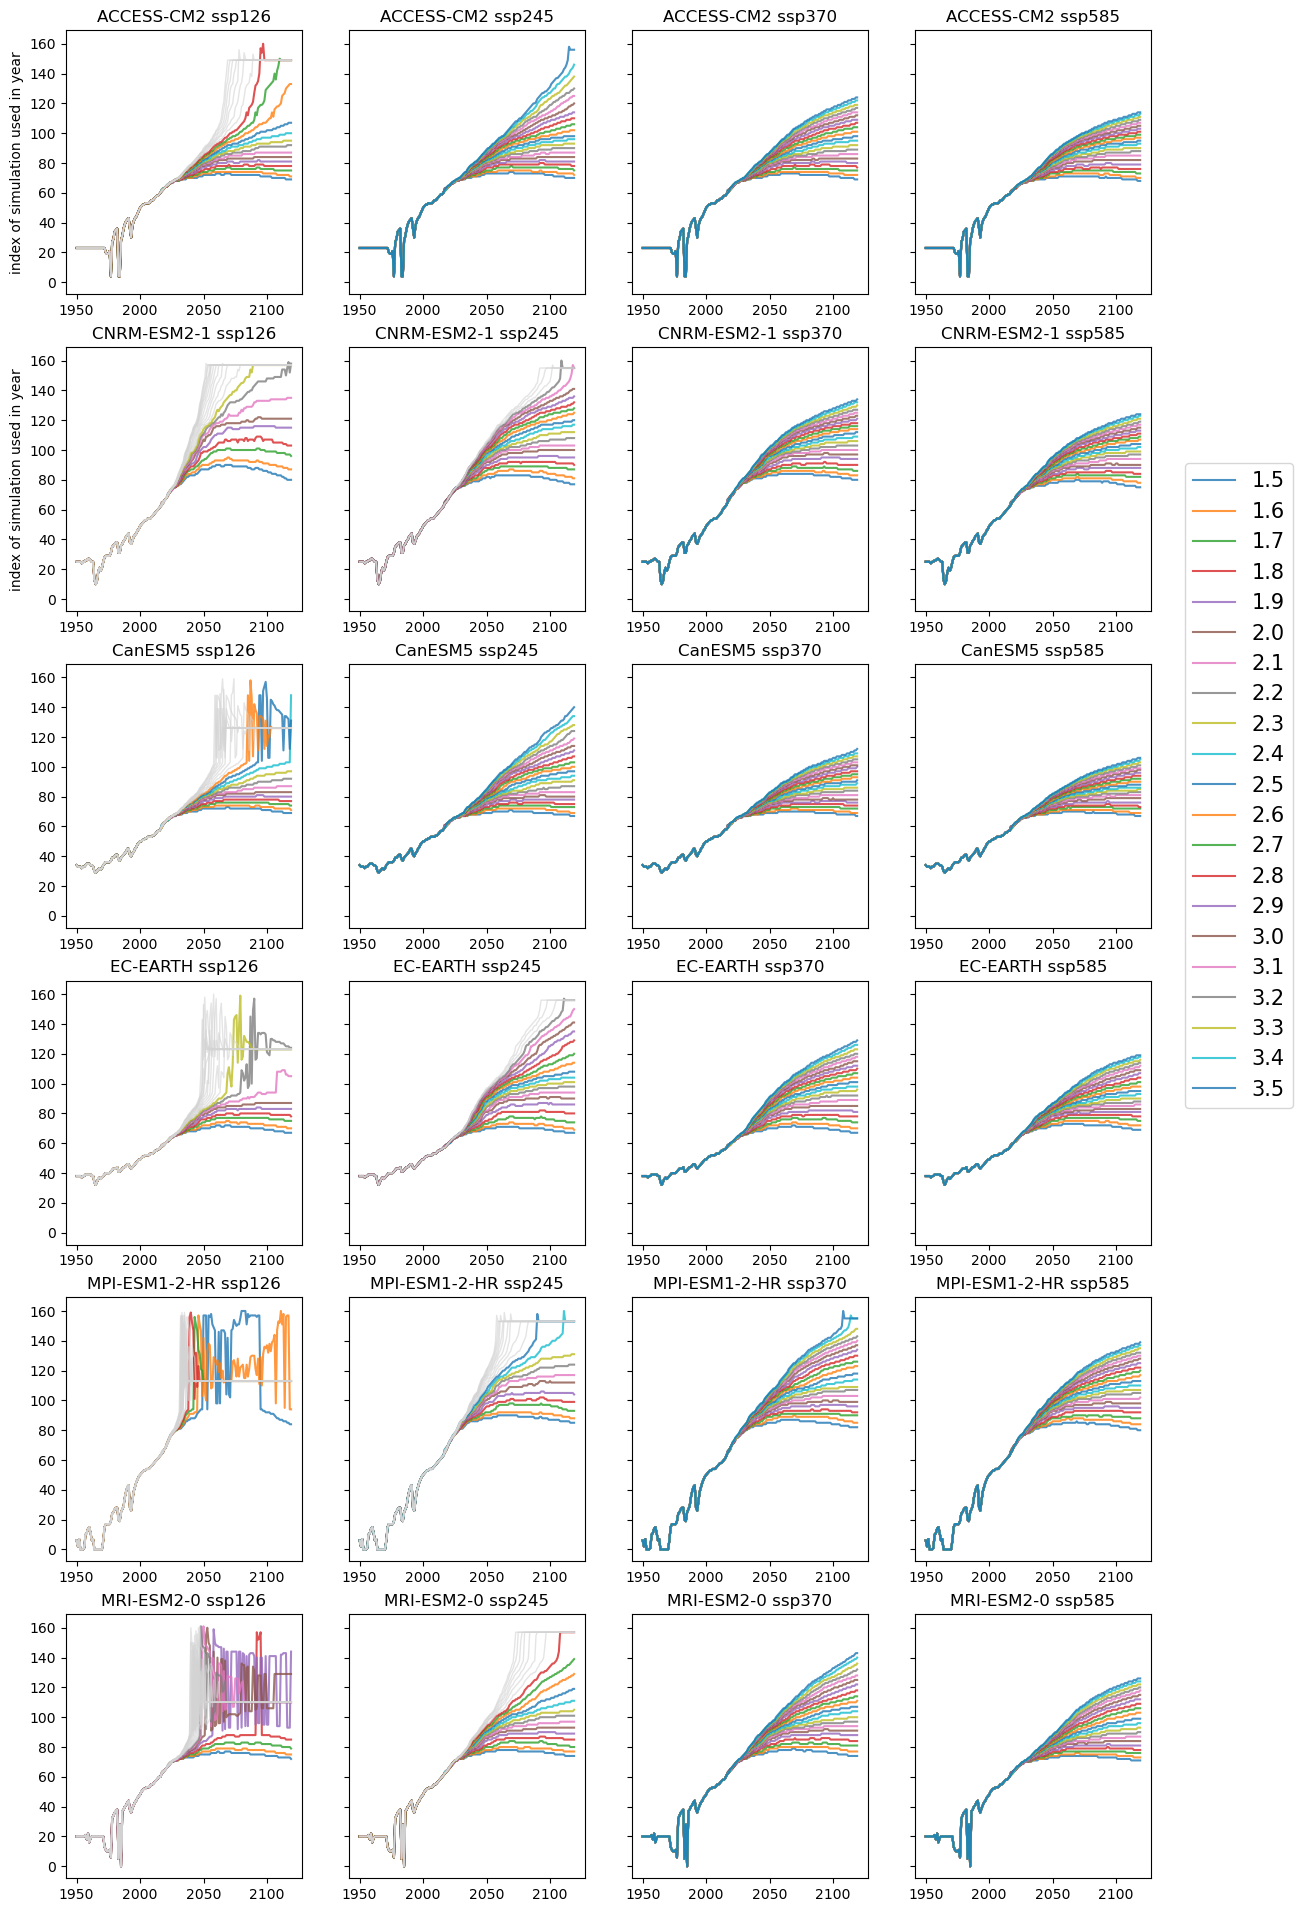

In [78]:

nrows=6

fig, axes = plt.subplots(nrows,4,figsize=(14,4*nrows),sharey=True)

axes=axes.flatten()

for i, ax in enumerate(axes):

    i+=1

    df_mapping = pd.DataFrame(data =d_climate_data_meta[i]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
    valid = np.array(d_climate_data_meta[i]['GMT_strj_valid'])  # your 0/1 array

    for col, is_valid in zip(df_mapping.columns, valid):
        if is_valid:
            ax.plot(df_mapping.index, df_mapping[col], lw=1.5, alpha=0.8,label=col)
        else:
            ax.plot(df_mapping.index, df_mapping[col], color='lightgray', lw=1.0, alpha=0.6)


    ax.set_title(d_climate_data_meta[i]['model']+' '+d_climate_data_meta[i]['scenario'])

    if i==1 or i==5:
        ax.set_ylabel('index of simulation used in year')
    
    if i==4:
        ax.legend(loc='upper left', bbox_to_anchor=(1.1, -0.6), fontsize=15)
    

## 2e. compare first years of stylized trajs with ERA5 - smooth the first years??

In [9]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=False
)

In [14]:


filepath_gmt_obs = '../data/gmst-obs/GCH_time_series_of_annual_global_temperatures_1850-2024_wrt_1991-2020.csv'

gmt_obs = pd.read_csv(filepath_gmt_obs,skiprows=3,index_col=0, na_values=-999,usecols=[0,1,2,3,4,5])


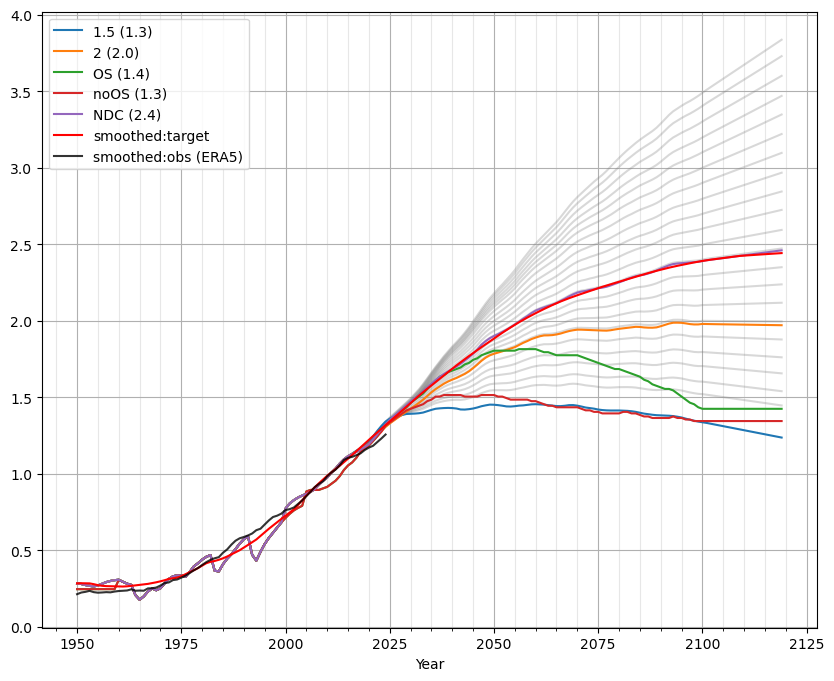

In [23]:
fig, ax = plt.subplots(figsize=(10,8))

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

df.squeeze().rolling(21,min_periods=1,center=True).mean().plot(ax=ax, label='smoothed:target', c='red')



gmt_obs['ERA5'].loc[1950:].rolling(21,min_periods=1,center=True).mean().plot(ax=ax, c='k', alpha=.8, label='smoothed:obs (ERA5)')

plt.legend(loc='upper left')

ax.grid(True, which='minor', alpha=0.3)

ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))


plt.grid()

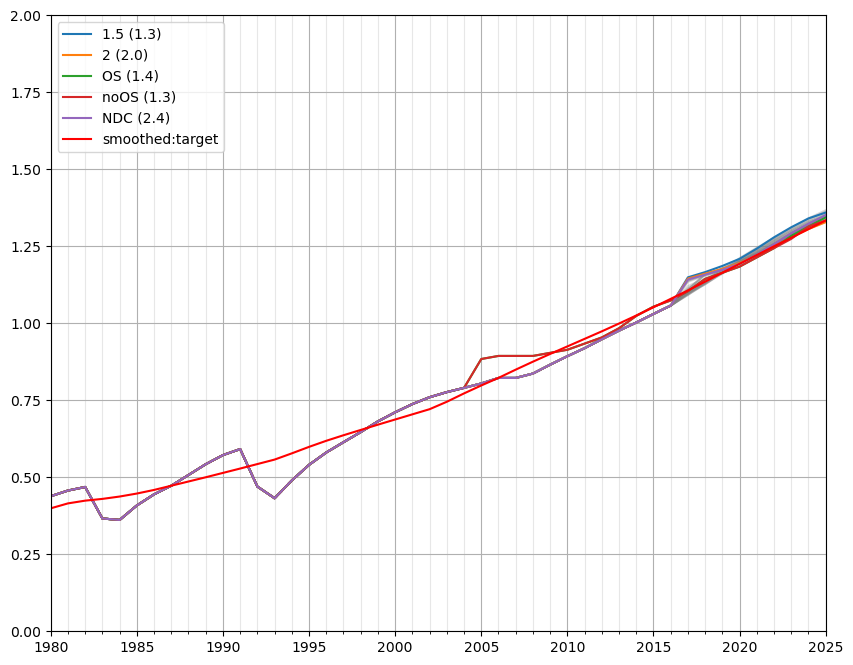

In [79]:
fig, ax = plt.subplots(figsize=(10,8))

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

df.squeeze().rolling(21,min_periods=1,center=True).mean().plot(ax=ax, label='smoothed:target', c='red')



#gmt_obs['ERA5'].loc[1950:].rolling(21,min_periods=1,center=True).mean().plot(ax=ax, c='k', alpha=.8, label='smoothed:obs (ERA5)')

plt.legend(loc='upper left')

ax.grid(True, which='minor', alpha=0.3)

ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))

ax.set_xlim(1980,2025)
ax.set_ylim(0,2)

plt.grid()

In [9]:
df.loc[:2015]

,2.4
1950,0.283403
1951,0.28426
1952,0.284042
1953,0.283287
1954,0.278158
...,...
2011,1.006373
2012,1.033262
2013,1.065928
2014,1.093617


## 2f. smooth first years of stylized trajs and re-run GMT-mapping

In [80]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=True
)

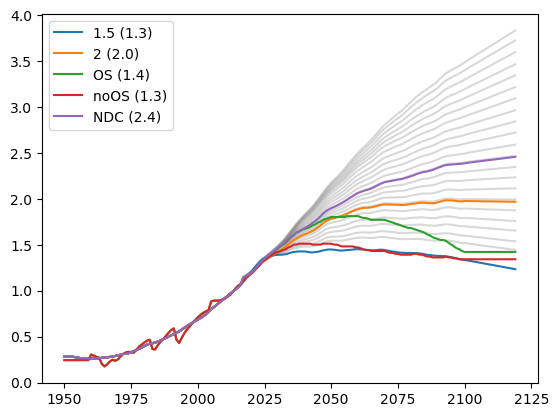

In [9]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

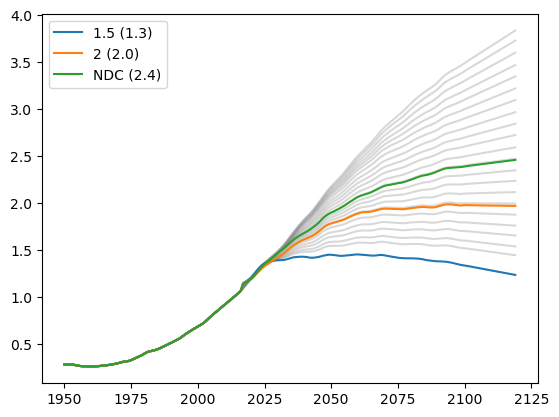

In [ ]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

# OS noOS are not smoothed !! should I ? Maybe for consistency

(0.0, 2.0)

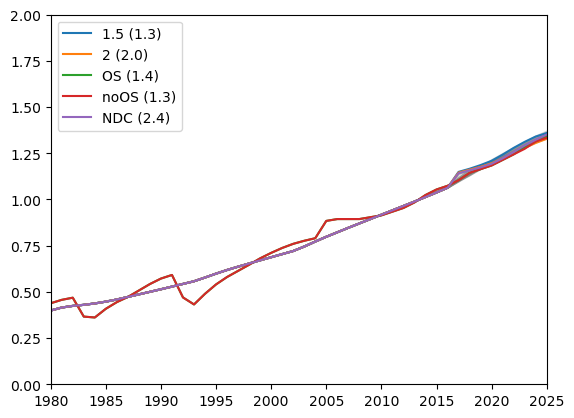

In [10]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

ax.set_xlim(1980,2025)
ax.set_ylim(0,2)

In [81]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']

In [82]:
d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs,                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS],
    GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS'],
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=1,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for FWI95d
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp245/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp370/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_A

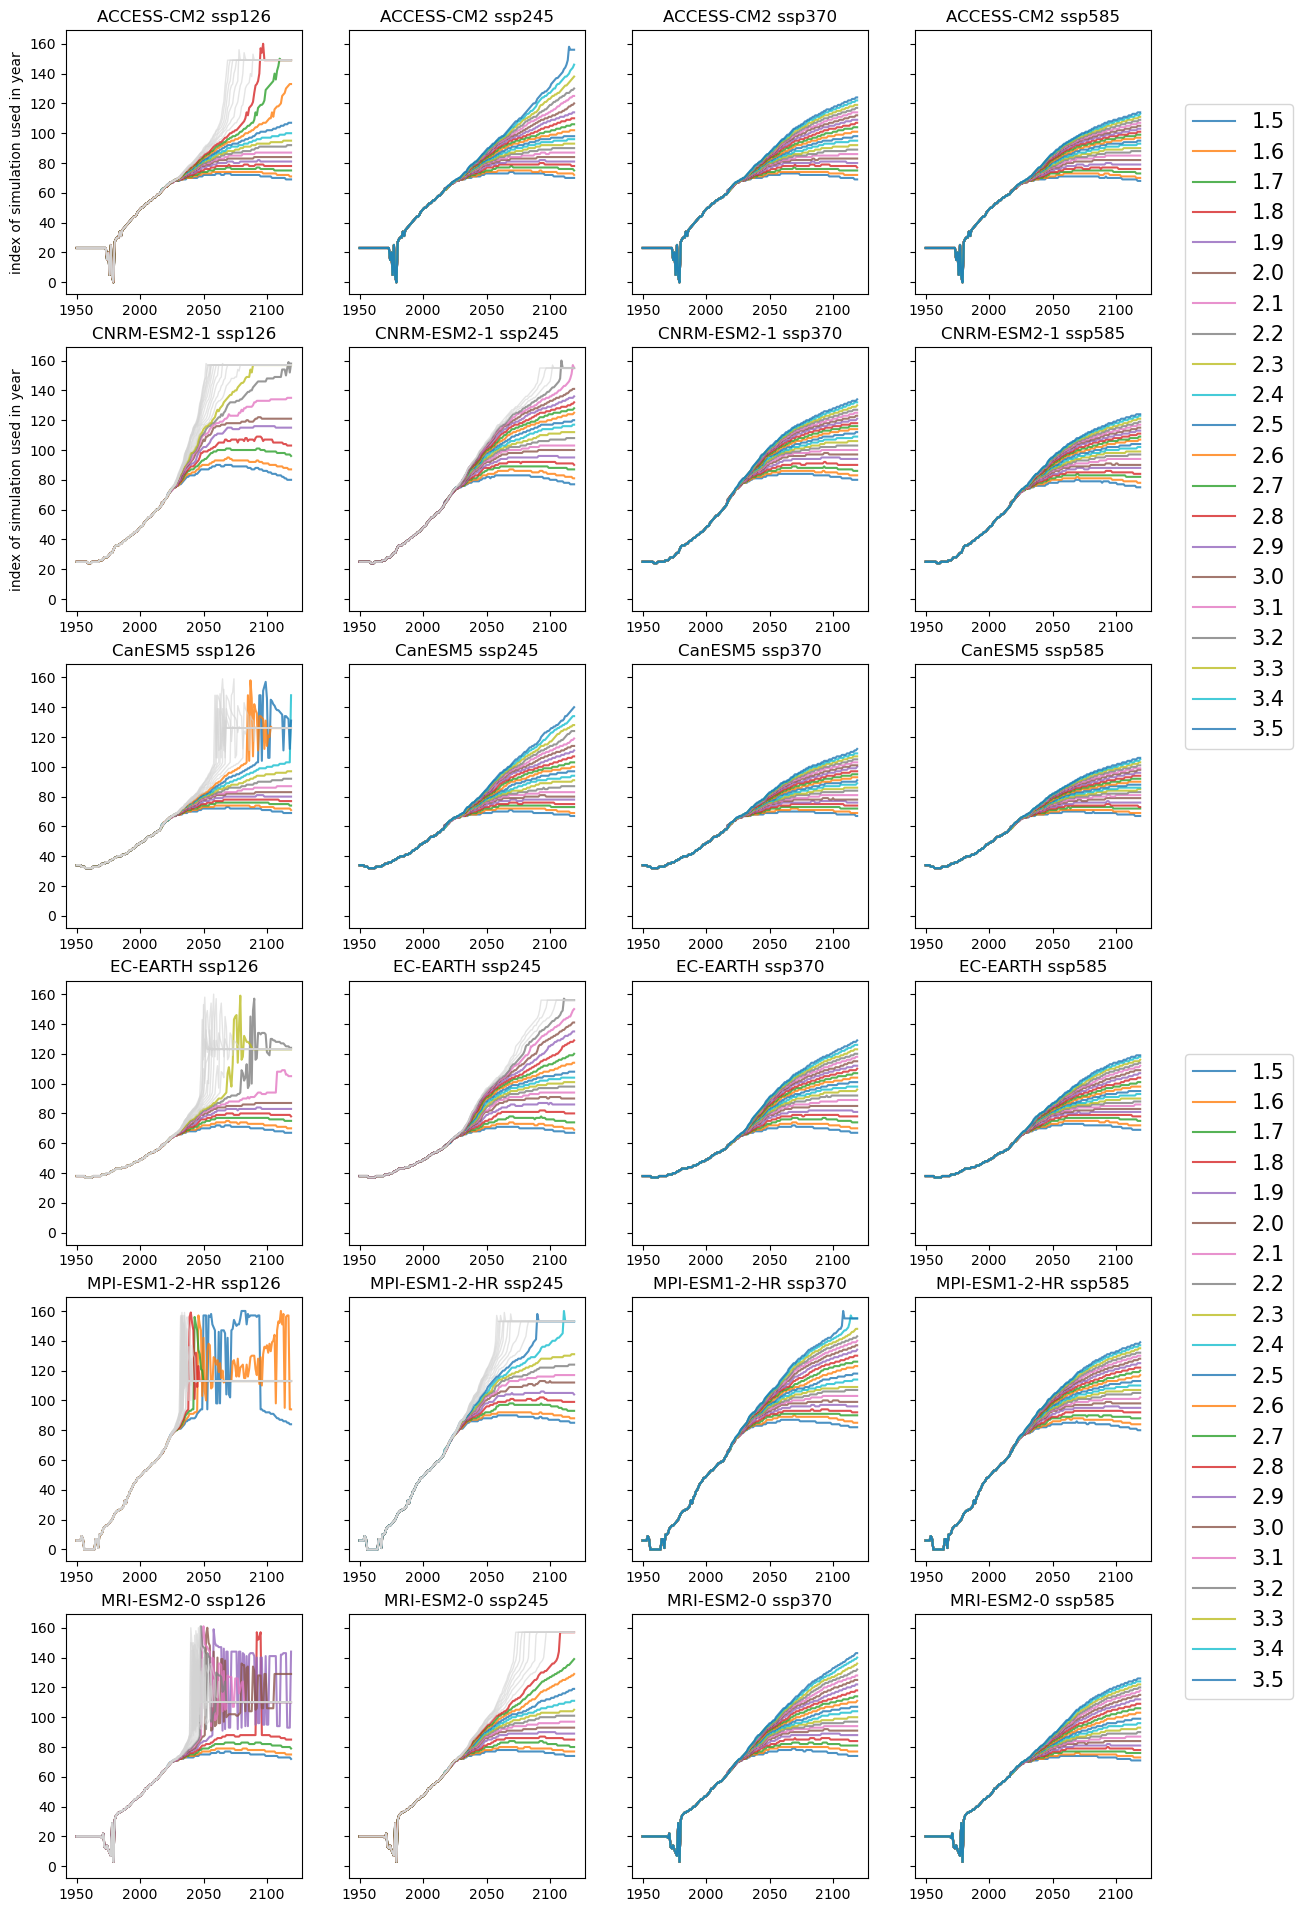

In [90]:

nrows=6

fig, axes = plt.subplots(nrows,4,figsize=(14,4*nrows),sharey=True)

axes=axes.flatten()

for i, ax in enumerate(axes):

    i+=1

    df_mapping = pd.DataFrame(data =d_climate_data_meta[i]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
    valid = np.array(d_climate_data_meta[i]['GMT_strj_valid'])  # your 0/1 array

    for col, is_valid in zip(df_mapping.columns, valid):
        if is_valid:
            ax.plot(df_mapping.index, df_mapping[col], lw=1.5, alpha=0.8,label=col)
        else:
            ax.plot(df_mapping.index, df_mapping[col], color='lightgray', lw=1.0, alpha=0.6)


    ax.set_title(d_climate_data_meta[i]['model']+' '+d_climate_data_meta[i]['scenario'])

    if i==1 or i==5:
        ax.set_ylabel('index of simulation used in year')
    
    if i==4 or i==16:
        ax.legend(loc='center left', bbox_to_anchor=(1.1, -0.5), fontsize=15)

### Sensitivity tests

1) Try threshold of .1 - doesnt help, just lots of scenarios lost 

In [21]:
d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs,                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS],
    GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS'],
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=1,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .1, 
    )

Processing climate data
Processing for FWI95d
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp245/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp370/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_A

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


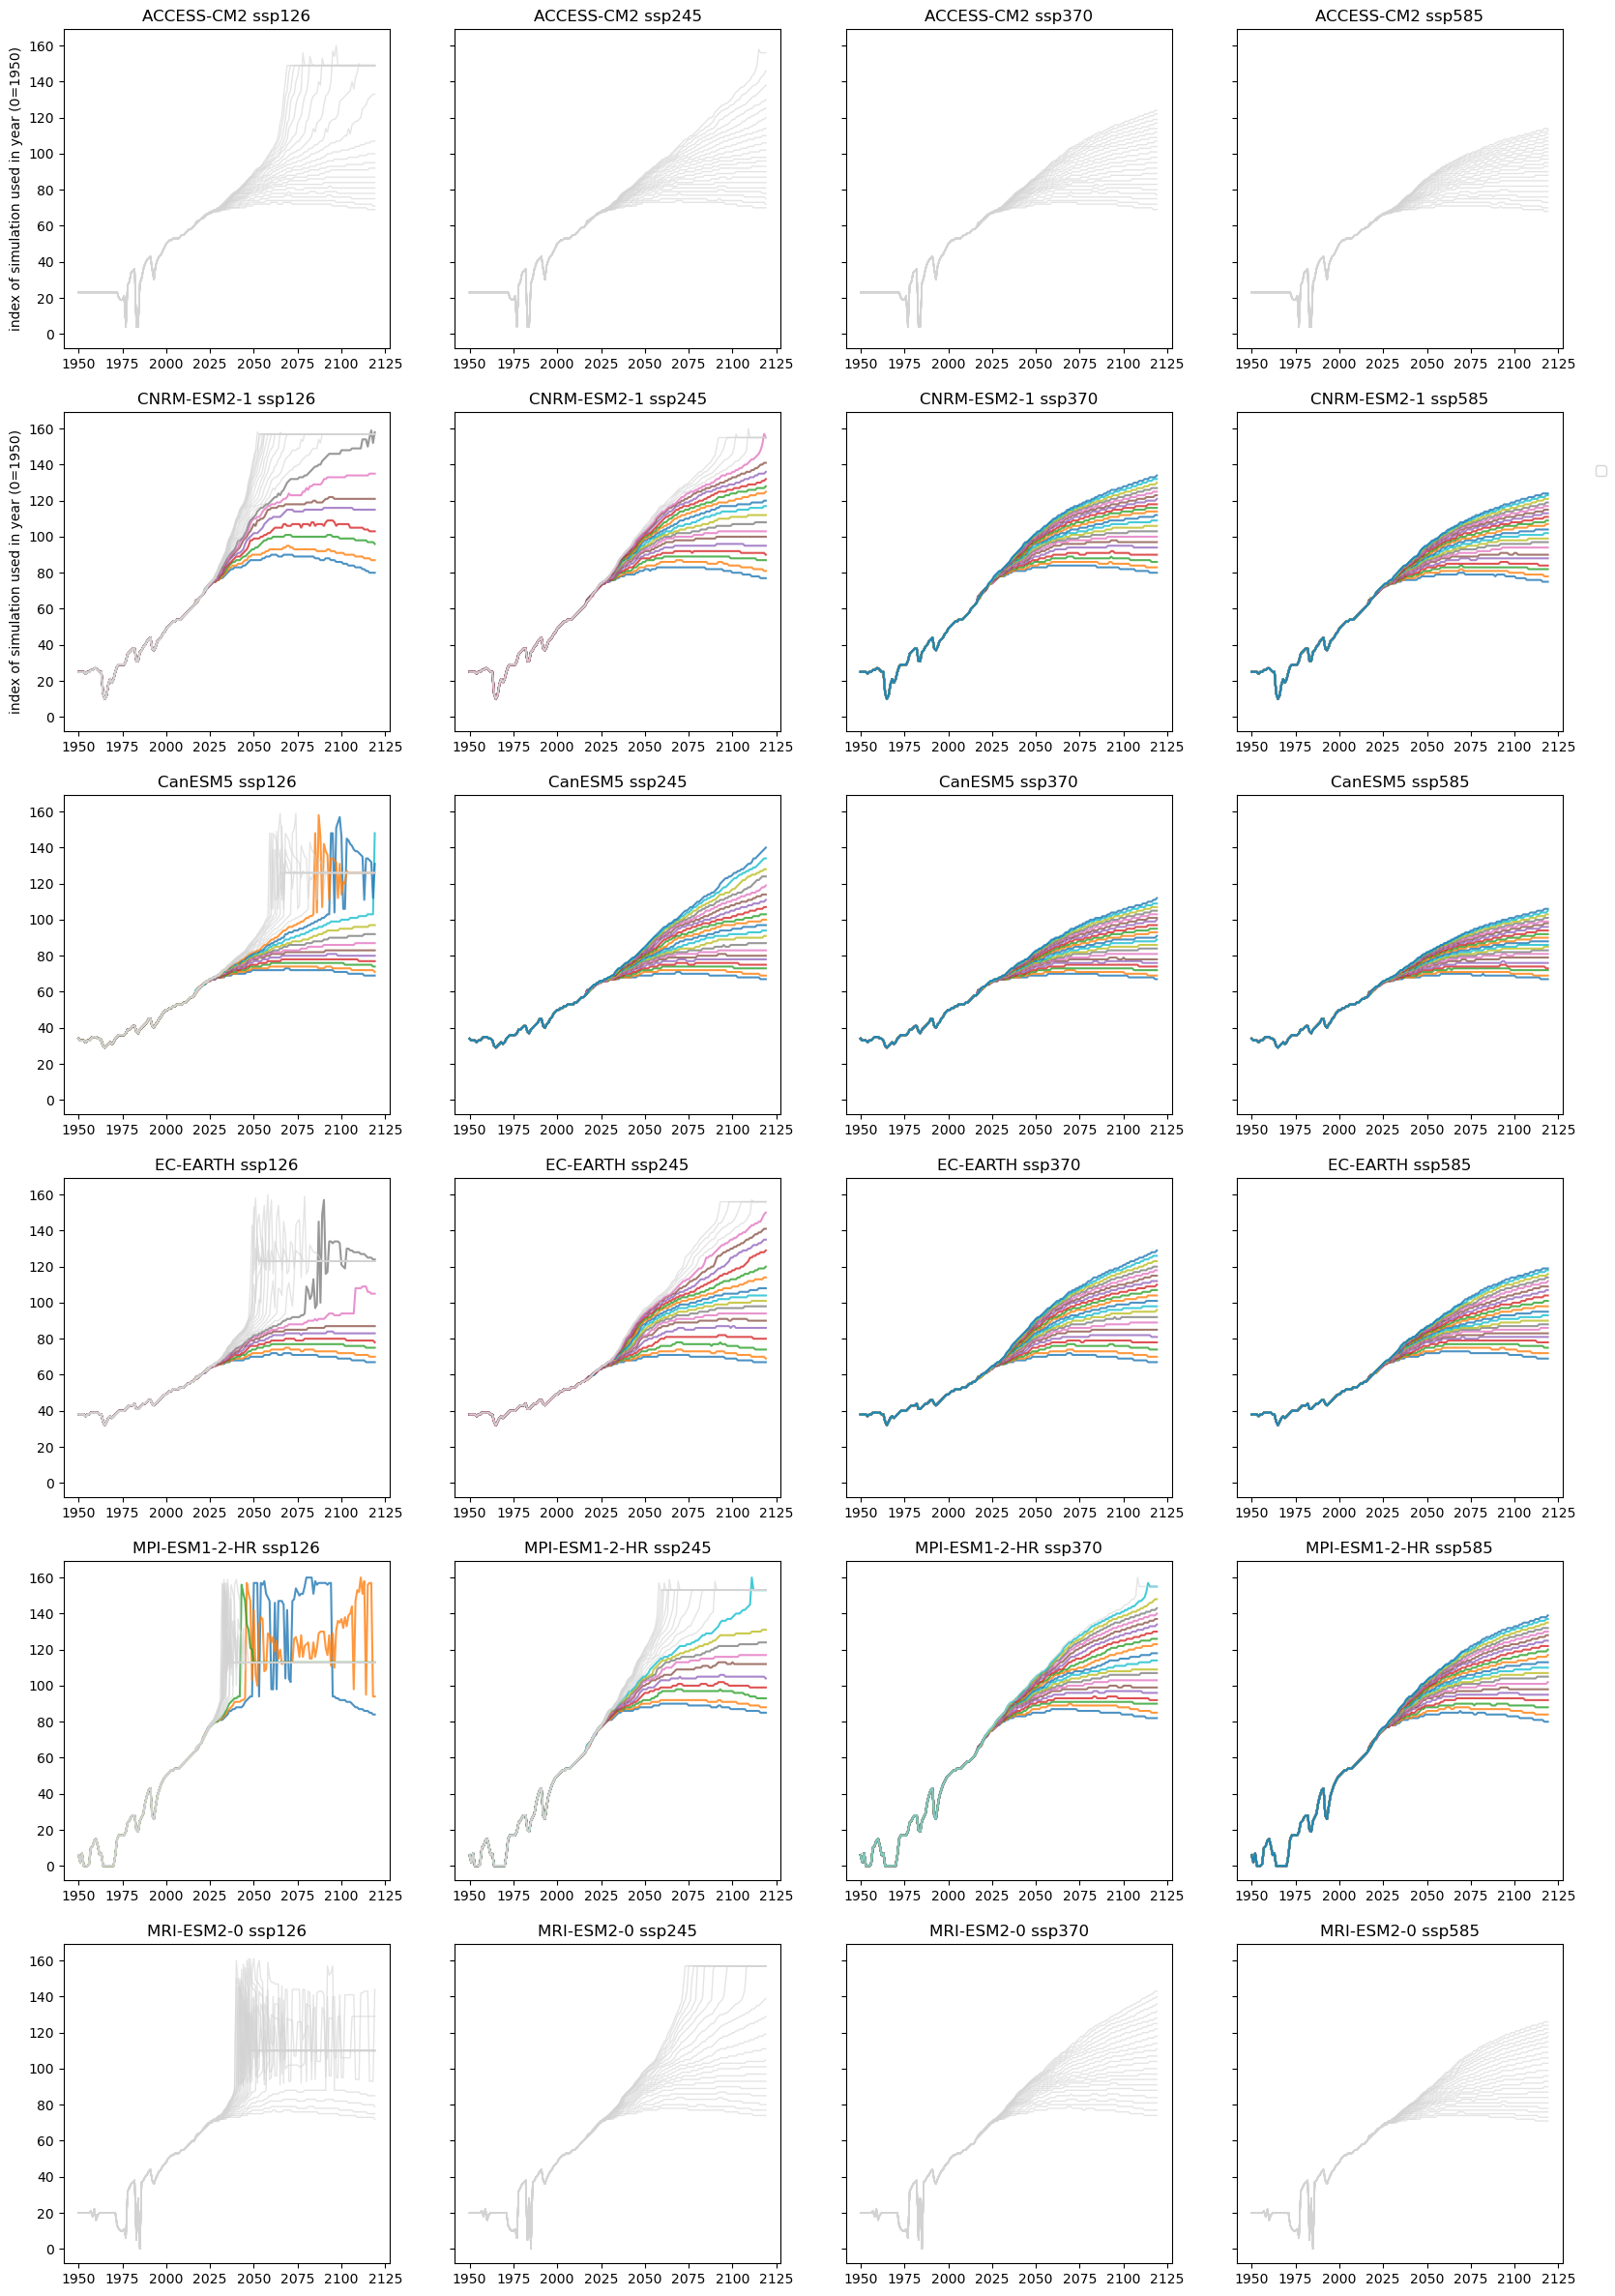

In [23]:
nrows=6

fig, axes = plt.subplots(nrows,4,figsize=(20,5*nrows),sharey=True)

axes=axes.flatten()

for i, ax in enumerate(axes):

    i+=1

    df_mapping = pd.DataFrame(data =d_climate_data_meta[i]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
    valid = np.array(d_climate_data_meta[i]['GMT_strj_valid'])  # your 0/1 array

    for col, is_valid in zip(df_mapping.columns, valid):
        if is_valid:
            ax.plot(df_mapping.index, df_mapping[col], lw=1.5, alpha=0.8,label=col)
        else:
            ax.plot(df_mapping.index, df_mapping[col], color='lightgray', lw=1.0, alpha=0.6)


    ax.set_title(d_climate_data_meta[i]['model']+' '+d_climate_data_meta[i]['scenario'])

    if i==1 or i==5:
        ax.set_ylabel('index of simulation used in year (0=1950)')
    
    if i==4:
        ax.legend(loc=(1.1,-.4))

# 3) Land fraction exposed

In [2]:

d_countries = preprocess_all_country_data(

    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    data_source_cohorts='UNWPP2024',
    extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    dir_population= dir_population,     # gridded pop data 
    ssp=2,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    bbox = bbox_europe,                        # could use bbox europe!!

    filepath_countrymask = filepath_countrymask,    # country masks 
    data_source_countrymask = 'shapefile',
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_world_bank = filepath_world_bank_meta, # metadata 
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 
    )


load_country_metadata took 0.06 s
load_unwpp_lifeexpectancy took 20.61 s
get_life_expectancies took 0.00 s
loading cohort sizes from UNWPP2024
load_cohort_sizes took 23.15 s
interpolate_cohortsize_countries took 0.01 s
opening compass - historical
opening compass - ssp2
load_population took 4.92 s
load_countrymask took 3.10 s
preprocess_all_country_data took 51.88 s


In [3]:
df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] 
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
df_birthyears = d_countries['birth_years'] # NA
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
countries_regions, countries_mask = d_countries['mask'] 

In [4]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=False

)

In [5]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']


d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs[0:2],                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS],
    GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS'],
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=1,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for FWI95d
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp245/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp370/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_A

In [129]:
len(d_climate_data_meta)

8

## develop

Try to make ds_regions object automatically from the data, that is used in calc_landfraction_exposed !


In [6]:
# check old object

ds_regions = pk.load(open('/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/Source2Suffering/data/pickles_S2S_dem4cli/country/ds_regions.pkl', 'rb'))

In [7]:
ds_regions['name']

<xarray.DataArray 'name' (region: 12)>
array(['East Asia & Pacific', 'Europe & Central Asia', 'High income',
       'Latin America & Caribbean', 'Low income', 'Lower middle income',
       'Middle East & North Africa', 'North America', 'South Asia',
       'Sub-Saharan Africa', 'Upper middle income', 'World'], dtype=object)
Coordinates:
  * region   (region) int64 0 1 2 3 4 5 6 7 8 9 10 11

In [8]:
df_countries

,abbreviation,region,incomegroup,country_code,SSP name,name,population
name,,,,,,,
Afghanistan,AFG,South Asia,Low income,4,Afghanistan,Afghanistan,4.485156e+07
Albania,ALB,Europe & Central Asia,Upper middle income,8,Albania,Albania,2.585156e+06
Algeria,DZA,Middle East & North Africa,Upper middle income,12,Algeria,Algeria,4.531977e+07
Angola,AGO,Sub-Saharan Africa,Lower middle income,24,Angola,Angola,2.623632e+07
Argentina,ARG,Latin America & Caribbean,Upper middle income,32,Argentina,Argentina,4.580178e+07
...,...,...,...,...,...,...,...
United States Virgin Islands,VIR,Latin America & Caribbean,High income,850,United States Virgin Islands,United States Virgin Islands,4.068623e+04
State of Palestine,PSE,Middle East & North Africa,Lower middle income,275,Palestine,State of Palestine,6.316836e+06
Yemen,YEM,Middle East & North Africa,Low income,887,Yemen,Yemen,3.761490e+07


In [9]:
gdf_country_borders

,geometry,region,abbreviation
name,,,
Afghanistan,"POLYGON ((71.04980 38.40866, 71.05714 38.40903...",South Asia,AFG
Albania,"POLYGON ((19.74777 42.57890, 19.74601 42.57993...",Europe & Central Asia,ALB
Algeria,"POLYGON ((8.60251 36.93951, 8.60566 36.91305, ...",Middle East & North Africa,DZA
Angola,"MULTIPOLYGON (((11.73752 -16.69258, 11.73851 -...",Sub-Saharan Africa,AGO
Argentina,"MULTIPOLYGON (((-68.65412 -54.88624, -68.65414...",Latin America & Caribbean,ARG
...,...,...,...
United States Virgin Islands,"MULTIPOLYGON (((-64.73078 17.76529, -64.70971 ...",Latin America & Caribbean,VIR
State of Palestine,"MULTIPOLYGON (((34.26440 31.22419, 34.24835 31...",Middle East & North Africa,PSE
Yemen,"MULTIPOLYGON (((53.30824 12.11839, 53.31027 12...",Middle East & North Africa,YEM


In [10]:
countries_mask

<xarray.DataArray 'mask' (lat: 360, lon: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    standard_name:  region
    flag_values:    [  1   2   3   5   6   7  10  11  12  13  14  15  16  17 ...
    flag_meanings:  AFG AGO ALB ARE ARG ARM AUS AUT AZE BDI BEL BEN BFA BGD B...

In [11]:
countries_regions

<regionmask.Regions 'country'>
overlap:  None

Regions:
  0 ABW        Aruba
  1 AFG  Afghanistan
  2 AGO       Angola
  3 ALB      Albania
  4 AND      Andorra
 ..  ..          ...
212 WSM        Samoa
213 YEM        Yemen
214 ZAF South Africa
215 ZMB       Zambia
216 ZWE     Zimbabwe

[217 regions]

In [12]:
df_countries['region'].unique()

array(['South Asia', 'Europe & Central Asia',
       'Middle East & North Africa', 'Sub-Saharan Africa',
       'Latin America & Caribbean', 'East Asia & Pacific',
       'North America'], dtype=object)

In [13]:
df_countries['incomegroup'].dropna().unique()

array(['Low income', 'Upper middle income', 'Lower middle income',
       'High income'], dtype=object)

In [15]:
df_countries.region.unique()

array(['South Asia', 'Europe & Central Asia',
       'Middle East & North Africa', 'Sub-Saharan Africa',
       'Latin America & Caribbean', 'East Asia & Pacific',
       'North America'], dtype=object)

In [6]:
# new see in landfrac exposed also !

region_names = np.concatenate([df_countries['region'].dropna().unique(),
                        df_countries['incomegroup'].dropna().unique(),
                        ['World']
])
region_names

array(['Europe & Central Asia', 'Middle East & North Africa',
       'Upper middle income', 'High income', 'Lower middle income',
       'World'], dtype=object)

In [7]:
year_start=1950
year_end=2119
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']

In [8]:
# 1) Build Dataset for regions result

region_names = np.concatenate([df_countries['region'].dropna().unique(),
                        df_countries['incomegroup'].dropna().unique(),
                        ['World']
])

nregions = len(region_names)


year_range = np.arange(year_start, year_end)

# Shared shape for all variables
shape = (len(d_climate_data_meta), nregions, len(year_range))

# Build the data_vars dictionary in a loop
data_vars = {}
var_suffixes = GMT_extra_trajectories_names
for suffix in var_suffixes:
    var_name = f'landfrac_peryear_perregion_{suffix}'
    data_vars[var_name] = (
        ['run', 'region', 'time_ind'],
        np.full(shape, np.nan)
    )

# Build the dataset
ds_lfe_perregion_perrun = xr.Dataset(
    data_vars=data_vars,
    coords={
        'run': ('run', np.arange(1, len(d_climate_data_meta) + 1)),
        'region': ('region', np.arange(0, nregions)),
        'time_ind': ('time_ind', np.arange(0, len(year_range), 1))
    }
)


# 2) Build Dataset for country result


# Shared shape for all variables
shape = (
    len(d_climate_data_meta),
    len(df_countries['name'].values),
    len(np.arange(0, len(year_range), 1))
)

# Build the data_vars dictionary in a loop
data_vars = {}
for suffix in var_suffixes:
    var_name = f'landfrac_peryear_percountry_{suffix}'
    data_vars[var_name] = (
        ['run', 'country', 'time_ind'],
        np.full(shape, np.nan)
    )

# Build the dataset
ds_lfe_percountry_perrun = xr.Dataset(
    data_vars=data_vars,
    coords={
        'run': ('run', np.arange(1, len(d_climate_data_meta) + 1)),
        'country': ('country', df_countries['name'].values),
        'time_ind': ('time_ind', np.arange(0, len(year_range), 1))
    }
)



In [9]:
ds_lfe_percountry_perrun

<xarray.Dataset>
Dimensions:                           (run: 8, country: 52, time_ind: 169)
Coordinates:
  * run                               (run) int64 1 2 3 4 5 6 7 8
  * country                           (country) object 'Albania' ... 'United ...
  * time_ind                          (time_ind) int64 0 1 2 3 ... 166 167 168
Data variables:
    landfrac_peryear_percountry_15    (run, country, time_ind) float64 nan .....
    landfrac_peryear_percountry_20    (run, country, time_ind) float64 nan .....
    landfrac_peryear_percountry_NDC   (run, country, time_ind) float64 nan .....
    landfrac_peryear_percountry_OS    (run, country, time_ind) float64 nan .....
    landfrac_peryear_percountry_noOS  (run, country, time_ind) float64 nan .....

In [10]:
ds_lfe_perregion_perrun

<xarray.Dataset>
Dimensions:                          (run: 8, region: 6, time_ind: 169)
Coordinates:
  * run                              (run) int64 1 2 3 4 5 6 7 8
  * region                           (region) int64 0 1 2 3 4 5
  * time_ind                         (time_ind) int64 0 1 2 3 ... 166 167 168
Data variables:
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 nan ... nan

### todo: add strj also ! different shape 

In [11]:
d_climate_data_meta

{1: {'extreme': 'FWI95d',
  'model': 'ACCESS-CM2',
  'scenario': 'ssp126',
  'GMT':            tas
  1950  0.385547
  1951  0.393164
  1952  0.393677
  1953  0.379471
  1954  0.362028
  ...        ...
  2115  2.769605
  2116  2.769605
  2117  2.769605
  2118  2.769605
  2119  2.769605
  
  [170 rows x 1 columns],
  'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
  'GMT_strj_valid': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]),
  'ind_RCP2GMT_strj': array([[ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         ...,
         [ 69,  72,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149]]),
  'GMT_15_maxdiff': 0.14355040795676718,
  'GMT_15_valid': True,
  'ind_RCP2GMT_15': array([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
         23, 23, 23, 23, 23

### calc exposure

In [12]:
def get_countries_of_region(
    region, 
    df_countries,
): 

    # Get list of member countries from region
    member_countries = df_countries.loc[df_countries['region']==region]['name'].values

    # not region but income group
    if len(member_countries) == 0: 
        member_countries = df_countries.loc[df_countries['incomegroup']==region]['name'].values

    # get all countries for the world
    if region == 'World':
        member_countries = df_countries['name'].values

    return member_countries 



#%%




In [84]:

@timeit
def load_climate_data_array(climatedata_dir,
                    scenario,
                    model,
                    extreme,
                    startyear,
                    endyear,
                    bbox=None
                    ):

    # Auxiliary function to slice  dataset to a particular region and time 
    def cut_to_region_time(da):
        # rename for compatibility with population objects
        if 'latitude' in da.coords:
            da = da.rename({'latitude':'lat', 'longitude':'lon'})
        # slice time
        if da.time.dtype == 'datetime64[ns]':
            da['time'] = da['time'].dt.year
        else:
            da['time'] = da['time'].astype(int) + startyear_ssp
        # cut space
        if bbox is None:
            return da.sel(time=slice(startyear, endyear))
        latmin, latmax, lonmin, lonmax = bbox 
        if da.lat.values[0] < da.lat.values[-1]: # check if lat is increasing or decreasing
            return da.sel(
                lat=slice(latmin, latmax), lon=slice(lonmin, lonmax), time=slice(startyear, endyear)
                )
        else:
            return da.sel(
                lat=slice(latmax, latmin), lon=slice(lonmin, lonmax), time=slice(startyear, endyear)
                )

    # Load climate data: annual count of exceedances of threshold
    # TODO: remove this from load_cliamte_data()

    # filepath = glob.glob(os.path.join(climatedata_dir, scenario, model, f'*{model}*{extreme}.nc'))[0]
    # print(f'Loading {filepath}')
    # da_rcp = xr.open_dataarray(filepath,chunks='auto')

    # #load associated historical variable
    # filepath = glob.glob(os.path.join(climatedata_dir, 'historical', model, f'*{model}*{extreme}.nc'))[0]
    # print(f'Loading {filepath}')
    # da_hist = xr.open_dataarray(filepath,chunks='auto')

    # # concat (AFA = area fraction affected, binary data yes/no affected)
    # da_AFA = xr.concat([da_hist,da_rcp], dim='time')
    # da_AFA['time'] = da_AFA.time.dt.year
    
    filepath_hist = glob.glob(os.path.join(climatedata_dir, 'historical', model, f'*{model}*{extreme}.nc'))[0]
    filepath_rcp = glob.glob(os.path.join(climatedata_dir, scenario, model, f'*{model}*{extreme}.nc'))[0]
    print(f'Loading {filepath_hist}')
    print(f'Loading {filepath_rcp}')
    da_AFA = xr.open_mfdataset(
                [filepath_hist, filepath_rcp],
                combine='nested',
                concat_dim='time',
                decode_coords='all',
                preprocess=cut_to_region_time,
            )
    VAR = list(da_AFA.data_vars)[0]
    da_AFA = da_AFA[VAR]

    # 4) if needed, repeat mean of last 10 years until entire period of interest is covered - NOTE: do you need da_AFA here??? you're not using it in this fxn
    if da_AFA.time.max() < year_end: 
        da_AFA_lastyear = da_AFA.isel(time=slice(-10, None)).mean(dim='time').expand_dims(dim='time',axis=0)
        for year in range(da_AFA.time.max().values+1,year_end+1): 
            da_AFA = xr.concat([da_AFA,da_AFA_lastyear.assign_coords(time = [year])], dim='time')
            
    # # retain only period of interest
    # da_AFA = da_AFA.sel(time=slice(year_start,year_end))



    return da_AFA

In [ ]:

def calc_weighted_fldmean(
    da, 
    countries_mask,
    ind_country, 
    weights=None,
    areaweighted=False
):
    def get_lat_name(da):
        """Figure out what is the latitude coordinate for each dataset."""
        for lat_name in ['lat', 'latitude']:
            if lat_name in da.coords:
                return lat_name
        raise RuntimeError("Couldn't find a latitude coordinate")
    
    def weighted_mean(da, weights, areaweighted):
        """Return weighted mean of dataarray."""
        if weights is not None:
            # weight the AFA of the country under study by the size of its population over time at the grid cell or provide gridcell area file 
            # slice to save memory on alignment 
            if "time" in weights.dims:
                weights = weights.sel(time=da_masked.time)
        elif areaweighted: 
            lat = da[get_lat_name(da)]
            weights = np.cos(np.deg2rad(lat))        
        other_dims = set(da.dims) - {'time'}
        return da_masked.weighted(weights).mean(other_dims,skipna=True).reset_coords(drop=True)

    # match grids
    da = da.interp_like(countries_mask, method='linear')

    # only keeps the AFA data for the country under study, for the others a NaN value is attributed
    #if len(ind_country) == 1: 
    if np.isscalar(ind_country):

        da_masked = da.where(countries_mask == ind_country)
    
    # if more countries are provided, combine the different masks 
    elif len(ind_country) > 1:
        
        mask = countries_mask.isin(ind_country)
        da_masked = da.where(mask)

    da_weighted_fldmean = weighted_mean(da_masked, weights, areaweighted)

    del da_masked

    return da_weighted_fldmean

In [89]:
da_AFA = load_climate_data_array(    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc

                    scenario=scenarios[0],
                    model=GCMs[0],
                    extreme="FWI95d",
                    startyear=1950,
                    endyear=2119,
                    bbox=bbox_europe)

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.09 s


In [90]:
da_AFA 

<xarray.DataArray 'FWI95d' (time: 170, lat: 391, lon: 499)>
dask.array<concatenate, shape=(170, 391, 499), dtype=float64, chunksize=(86, 391, 499), chunktype=numpy.ndarray>
Coordinates:
  * lon       (lon) float64 -14.86 -14.76 -14.66 -14.56 ... 34.74 34.84 34.94
  * lat       (lat) float64 70.99 70.89 70.79 70.69 ... 32.29 32.19 32.09 31.99
    quantile  float64 0.95
  * time      (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119

In [91]:
da_population.lat.values

array([32.05, 32.15, 32.25, 32.35, 32.45, 32.55, 32.65, 32.75, 32.85,
       32.95, 33.05, 33.15, 33.25, 33.35, 33.45, 33.55, 33.65, 33.75,
       33.85, 33.95, 34.05, 34.15, 34.25, 34.35, 34.45, 34.55, 34.65,
       34.75, 34.85, 34.95, 35.05, 35.15, 35.25, 35.35, 35.45, 35.55,
       35.65, 35.75, 35.85, 35.95, 36.05, 36.15, 36.25, 36.35, 36.45,
       36.55, 36.65, 36.75, 36.85, 36.95, 37.05, 37.15, 37.25, 37.35,
       37.45, 37.55, 37.65, 37.75, 37.85, 37.95, 38.05, 38.15, 38.25,
       38.35, 38.45, 38.55, 38.65, 38.75, 38.85, 38.95, 39.05, 39.15,
       39.25, 39.35, 39.45, 39.55, 39.65, 39.75, 39.85, 39.95, 40.05,
       40.15, 40.25, 40.35, 40.45, 40.55, 40.65, 40.75, 40.85, 40.95,
       41.05, 41.15, 41.25, 41.35, 41.45, 41.55, 41.65, 41.75, 41.85,
       41.95, 42.05, 42.15, 42.25, 42.35, 42.45, 42.55, 42.65, 42.75,
       42.85, 42.95, 43.05, 43.15, 43.25, 43.35, 43.45, 43.55, 43.65,
       43.75, 43.85, 43.95, 44.05, 44.15, 44.25, 44.35, 44.45, 44.55,
       44.65, 44.75,

In [92]:
da_AFA.lat.values.round(2)

# not exactly same grid!!

array([70.99, 70.89, 70.79, 70.69, 70.59, 70.49, 70.39, 70.29, 70.19,
       70.09, 69.99, 69.89, 69.79, 69.69, 69.59, 69.49, 69.39, 69.29,
       69.19, 69.09, 68.99, 68.89, 68.79, 68.69, 68.59, 68.49, 68.39,
       68.29, 68.19, 68.09, 67.99, 67.89, 67.79, 67.69, 67.59, 67.49,
       67.39, 67.29, 67.19, 67.09, 66.99, 66.89, 66.79, 66.69, 66.59,
       66.49, 66.39, 66.29, 66.19, 66.09, 65.99, 65.89, 65.79, 65.69,
       65.59, 65.49, 65.39, 65.29, 65.19, 65.09, 64.99, 64.89, 64.79,
       64.69, 64.59, 64.49, 64.39, 64.29, 64.19, 64.09, 63.99, 63.89,
       63.79, 63.69, 63.59, 63.49, 63.39, 63.29, 63.19, 63.09, 62.99,
       62.89, 62.79, 62.69, 62.59, 62.49, 62.39, 62.29, 62.19, 62.09,
       61.99, 61.89, 61.79, 61.69, 61.59, 61.49, 61.39, 61.29, 61.19,
       61.09, 60.99, 60.89, 60.79, 60.69, 60.59, 60.49, 60.39, 60.29,
       60.19, 60.09, 59.99, 59.89, 59.79, 59.69, 59.59, 59.49, 59.39,
       59.29, 59.19, 59.09, 58.99, 58.89, 58.79, 58.69, 58.59, 58.49,
       58.39, 58.29,

In [93]:
countries_mask

<xarray.DataArray 'mask' (lat: 391, lon: 499)>
array([[nan, nan, nan, ..., nan, 93., 93.],
       [nan, nan, nan, ..., nan, nan, 93.],
       [nan, nan, nan, ..., nan, nan, 93.],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 32.05 32.15 32.25 32.35 ... 70.75 70.85 70.95 71.05
  * lon      (lon) float64 -14.95 -14.85 -14.75 -14.65 ... 34.65 34.75 34.85
Attributes:
    standard_name:  region
    flag_values:    [  3   4  11  14  18  21  22  33  47  48  49  52  54  58 ...
    flag_meanings:  ALB AND AUT BEL BGR BIH BLR CHE CYP CZE DEU DNK DZA ESP E...

In [94]:
region=region_names[0]

countries = get_countries_of_region(region, df_countries)
print(region)

Europe & Central Asia


In [95]:
countries

array(['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium',
       'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus',
       'Czechia', 'Denmark', 'Estonia', 'Faroe Islands', 'Finland',
       'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland',
       'Isle of Man', 'Italy', 'Kosovo (under UNSC res. 1244)', 'Latvia',
       'Liechtenstein', 'Lithuania', 'Luxembourg', 'Republic of Moldova',
       'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland',
       'Portugal', 'Romania', 'Russian Federation', 'San Marino',
       'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland',
       'Türkiye', 'Ukraine', 'United Kingdom'], dtype=object)

In [96]:
len(countries)

46

In [97]:
ind_country = countries_regions.map_keys(countries)
ind_country

[3,
 4,
 11,
 14,
 18,
 21,
 22,
 33,
 47,
 48,
 49,
 52,
 58,
 59,
 61,
 63,
 64,
 67,
 75,
 83,
 85,
 87,
 89,
 92,
 94,
 105,
 112,
 115,
 116,
 117,
 122,
 127,
 131,
 144,
 145,
 156,
 159,
 164,
 165,
 175,
 177,
 180,
 181,
 182,
 197,
 202]

In [98]:


da_weighted_region = calc_weighted_fldmean(
    da_AFA, 
    countries_mask,
    ind_country, 
    weights=None,
    areaweighted=True
).compute()

calc_weighted_fldmean took 0.02 s


In [99]:
da_weighted_region

<xarray.DataArray 'FWI95d' (time: 170)>
array([17.31233949, 15.91291682, 26.96916461, 17.4565478 , 17.63860629,
       12.98211787, 23.2897601 ,  9.74691301,  9.61371817, 16.20497287,
       14.51276555, 12.48203592, 13.51647428, 14.26905722, 16.01789435,
       10.40583982, 11.19317666, 13.0925282 , 13.46759926,  9.45930687,
        9.51317753, 15.16388622, 11.10961825, 14.52554476, 14.18742874,
       23.92358803, 23.61316874, 11.67631876, 11.01192581, 18.91341925,
       15.19134839, 11.78829914, 12.56226768, 12.48444276, 14.23668887,
       12.75566912,  7.67256158, 14.70940518, 23.80208462, 17.4246569 ,
       17.18323166, 14.71061638, 11.3758735 , 18.95224311, 17.09809909,
        9.62117047, 17.59180786, 21.00825051, 16.16031186, 15.03781687,
       21.21172927, 13.17868341, 22.70295029, 25.20987586, 16.61161594,
       18.60830964, 13.3095182 , 15.75708525, 21.9600806 , 21.93494305,
       22.36728539, 22.25073621, 15.33025071, 25.8122039 , 24.77852746,
       22.07593406, 16.41269277, 20.68842254, 22.83679786, 26.08579513,
       28.87995075, 20.20397166, 26.96846512, 34.75854366, 30.34744882,
       23.06027441, 25.5555835 , 23.23275661, 21.82390051, 34.22663234,
       25.37104392, 21.37271647, 29.80857481, 26.979551  , 31.26968503,
       43.89939082, 27.87675632, 29.95626979, 31.43709991, 31.85461185,
       21.55175111, 33.68765051, 51.41302992, 32.48252452, 30.13989149,
       25.78244673, 23.66466027, 19.7445864 , 29.69064815, 25.49334801,
       34.38850735, 23.29405321, 32.62407851, 22.93863854, 14.903334  ,
       29.70258689, 22.40773868, 41.66309329, 30.607886  , 41.41820588,
       23.54143182, 31.27702971, 36.84454267, 23.33472155, 35.15628604,
       32.8013407 , 37.24074787, 36.4373368 , 28.81398635, 25.06581904,
       33.25981595, 23.22659414, 31.83696712, 51.61209235, 29.30910036,
       22.84995698, 24.99597761, 29.72988517, 21.94469566, 41.68124813,
       46.84025733, 36.0493643 , 33.44597033, 30.4287128 , 31.08137428,
       27.56067611, 27.72591866, 32.57908381, 26.65564252, 37.20429008,
       33.12539492, 33.41214473, 26.69585625, 43.38262865, 29.40004528,
       41.42001021, 40.48957481, 38.66252495, 34.16754463, 27.14558935,
       29.00328301, 34.37792019, 34.37792019, 34.37792019, 34.37792019,
       34.37792019, 34.37792019, 34.37792019, 34.37792019, 34.37792019,
       34.37792019, 34.37792019, 34.37792019, 34.37792019, 34.37792019,
       34.37792019, 34.37792019, 34.37792019, 34.37792019, 34.37792019])
Coordinates:
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119

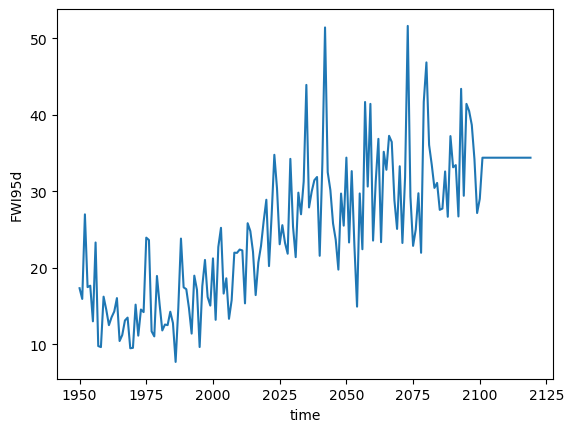

In [100]:
da_weighted_region.plot()

### reindex / remapping

In [130]:


    # 1) Build Dataset for regions result

    # get regions and income groups and 'World' (=all countries)
    region_names = np.concatenate([df_countries['region'].dropna().unique(),
                            df_countries['incomegroup'].dropna().unique(),
                            ['World'] # not sure how useful to keep 'World' if you are using a bbox! 
    ])

    nregions = len(region_names)

    # Shared shape for all variables
    year_range = np.arange(year_start, year_end+1)

    shape = (len(d_climate_data_meta), nregions, len(year_range))

    # Build the data_vars dictionary in a loop
    data_vars = {}
    var_suffixes = ['RCP']+GMT_extra_trajectories_names 
    for suffix in var_suffixes:
        var_name = f'landfrac_peryear_perregion_{suffix}'
        data_vars[var_name] = (
            ['run', 'region', 'time_ind'],
            np.full(shape, np.nan)
        )

    # Build the dataset
    ds_lfe_perregion_perrun = xr.Dataset(
        data_vars=data_vars,
        coords={
            'run': ('run', np.arange(1, len(d_climate_data_meta) + 1)),
            'region': ('region', np.arange(0, nregions)),
            'time_ind': ('time_ind', np.arange(0, len(year_range), 1))
        }
    )

    # 2) Build Dataset for country result

    # Shared shape for all variables
    shape = (
        len(d_climate_data_meta),
        len(df_countries['name'].values),
        len(np.arange(0, len(year_range), 1))
    )

    # Build the data_vars dictionary in a loop
    data_vars = {}
    for suffix in var_suffixes:
        var_name = f'landfrac_peryear_percountry_{suffix}'
        data_vars[var_name] = (
            ['run', 'country', 'time_ind'],
            np.full(shape, np.nan)
        )

    # Build the dataset
    ds_lfe_percountry_perrun = xr.Dataset(
        data_vars=data_vars,
        coords={
            'run': ('run', np.arange(1, len(d_climate_data_meta) + 1)),
            'country': ('country', df_countries['name'].values),
            'time_ind': ('time_ind', np.arange(0, len(year_range), 1))
        }
    )

In [131]:
weights=None
areaweighted=True

In [122]:
# loop over warming scenarios 
for suffix in var_suffixes:

    for ind_region,region in enumerate(region_names):

        print(f'Computing LFE in {region} for {suffix}')

        countries = get_countries_of_region(region, df_countries)

        ind_country = countries_regions.map_keys(countries)

        if suffix == 'RCP': # calc area-weighted fieldmean for each model year

            land_frac_perregion = calc_weighted_fldmean(da_AFA,countries_mask,ind_country,weights, areaweighted)

            ds_lfe_perregion_perrun[f'landfrac_peryear_perregion_{suffix}'].loc[{
                    'run' : i, 
                    'region' : ind_region
                }] = land_frac_perregion.values
        
        else: # remap based on indexes previously computed 

            ind_RCP = d_climate_data_meta[i][f'ind_RCP2GMT_{suffix}']

            # extract the relevant subset for this run and region
            src = ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].sel(run=i, region=ind_region)

            # assign remapped 
            ds_lfe_perregion_perrun[f'landfrac_peryear_perregion_{suffix}'].loc[dict(run=i, region=ind_region)] = src.isel(time_ind=ind_RCP).values




Computing LFE in Europe & Central Asia for RCP
calc_weighted_fldmean took 0.02 s
Computing LFE in Middle East & North Africa for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Upper middle income for RCP
calc_weighted_fldmean took 0.02 s
Computing LFE in High income for RCP
calc_weighted_fldmean took 0.02 s
Computing LFE in Lower middle income for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in World for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Europe & Central Asia for 15
Computing LFE in Middle East & North Africa for 15
Computing LFE in Upper middle income for 15
Computing LFE in High income for 15
Computing LFE in Lower middle income for 15
Computing LFE in World for 15
Computing LFE in Europe & Central Asia for 20
Computing LFE in Middle East & North Africa for 20
Computing LFE in Upper middle income for 20
Computing LFE in High income for 20
Computing LFE in Lower middle income for 20
Computing LFE in World for 20
Computing LFE in Europe & Central Asi

In [123]:
ds_lfe_perregion_perrun

<xarray.Dataset>
Dimensions:                          (run: 8, region: 6, time_ind: 170)
Coordinates:
  * run                              (run) int64 1 2 3 4 5 6 7 8
  * region                           (region) int64 0 1 2 3 4 5
  * time_ind                         (time_ind) int64 0 1 2 3 ... 167 168 169
Data variables:
    landfrac_peryear_perregion_RCP   (run, region, time_ind) float64 17.31 .....
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 14.53 .....

In [124]:
ds_lfe_perregion_perrun.data_vars

Data variables:
    landfrac_peryear_perregion_RCP   (run, region, time_ind) float64 17.31 .....
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 14.53 .....

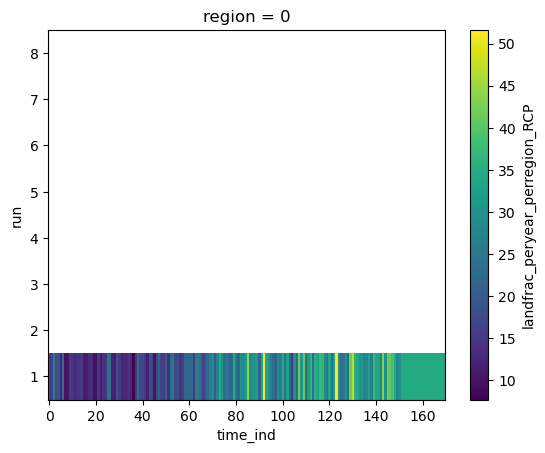

In [ ]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].sel(region=0).plot()


# it looks cool like this !! 

# fraction land pr year exposed to FWI95d exceedance !! Region=0 

In [138]:
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI'
startyear=1950
endyear=2119
bbox = bbox_europe

In [143]:
for i in list(d_climate_data_meta.keys()): 

    print('                         🟠 Remapping Simulation {} of {} 🟠\n'.format(i,len(d_climate_data_meta)))

    scenario = d_climate_data_meta[i]['scenario']
    model = d_climate_data_meta[i]['model']
    extreme = d_climate_data_meta[i]['extreme']

    da_AFA = load_climate_data_array(climatedata_dir,
                scenario,
                model,
                extreme,
                startyear,
                endyear,
                bbox
                )

    # loop over warming scenarios 
    for suffix in var_suffixes:

        for ind_region,region in enumerate(region_names):

            print(f'Computing LFE in {region} for {suffix}')

            countries = get_countries_of_region(region, df_countries)

            ind_country = countries_regions.map_keys(countries)

            if suffix == 'RCP': # calc area-weighted fieldmean for each model year

                land_frac_perregion = calc_weighted_fldmean(da_AFA,countries_mask,ind_country,weights, areaweighted)

                ds_lfe_perregion_perrun[f'landfrac_peryear_perregion_{suffix}'].loc[{
                        'run' : i, 
                        'region' : ind_region
                    }] = land_frac_perregion.values
            
            else: # remap based on indexes previously computed 

                ind_RCP = d_climate_data_meta[i][f'ind_RCP2GMT_{suffix}']

                # extract the relevant subset for this run and region
                src = ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].sel(run=i, region=ind_region)

                # assign remapped 
                ds_lfe_perregion_perrun[f'landfrac_peryear_perregion_{suffix}'].loc[dict(run=i, region=ind_region)] = src.isel(time_ind=ind_RCP).values


            pass


        for j, country in enumerate(df_countries['name']):

            print(f'Computing LFE in {country} for {suffix}')

            # calculate mean per country weighted by area
            ind_country = countries_regions.map_keys(country)
            
            if suffix =='RCP':
                landfrac_percountry = calc_weighted_fldmean(da_AFA,countries_mask,ind_country,weights, areaweighted)

                ds_lfe_percountry_perrun[f'landfrac_peryear_percountry_{suffix}'].loc[{
                        'run' : i, 
                        'country' : country
                    }] = landfrac_percountry.values

            else: # remap based on indexes previously computed 

                ind_RCP = d_climate_data_meta[i][f'ind_RCP2GMT_{suffix}']

                # extract the relevant subset for this run and region
                src = ds_lfe_percountry_perrun['landfrac_peryear_percountry_RCP'].sel(run=i, country=country)

                # assign remapped 
                ds_lfe_percountry_perrun[f'landfrac_peryear_percountry_{suffix}'].loc[dict(run=i, country=country)] = src.isel(time_ind=ind_RCP).values




                         🟠 Remapping Simulation 1 of 8 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.06 s
Computing LFE in Europe & Central Asia for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Middle East & North Africa for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Upper middle income for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in High income for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Lower middle income for RCP
calc_weighted_fldmean took 0.02 s
Computing LFE in World for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Albania for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Algeria for RCP
calc_weighted_fld

In [144]:
ds_lfe_perregion_perrun

<xarray.Dataset>
Dimensions:                          (run: 8, region: 6, time_ind: 170)
Coordinates:
  * run                              (run) int64 1 2 3 4 5 6 7 8
  * region                           (region) int64 0 1 2 3 4 5
  * time_ind                         (time_ind) int64 0 1 2 3 ... 167 168 169
Data variables:
    landfrac_peryear_perregion_RCP   (run, region, time_ind) float64 17.31 .....
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 14.53 .....

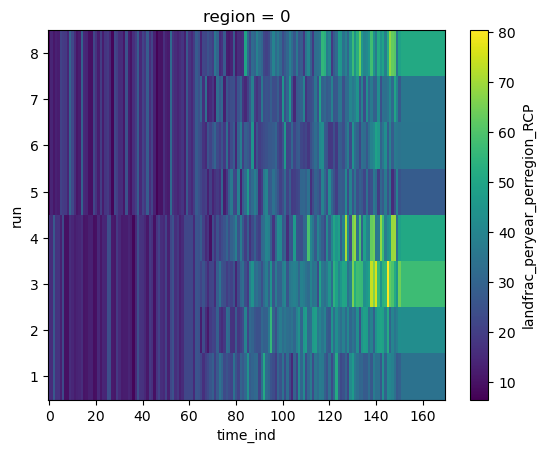

In [ ]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].sel(region=0).plot()

# print what model/rcp these are!!


In [151]:
for i in list(d_climate_data_meta.keys()):
    scenario = d_climate_data_meta[i]['scenario']
    model = d_climate_data_meta[i]['model']
    print(i, model, scenario)

1 ACCESS-CM2 ssp126
2 ACCESS-CM2 ssp245
3 ACCESS-CM2 ssp370
4 ACCESS-CM2 ssp585
5 CNRM-ESM2-1 ssp126
6 CNRM-ESM2-1 ssp245
7 CNRM-ESM2-1 ssp370
8 CNRM-ESM2-1 ssp585


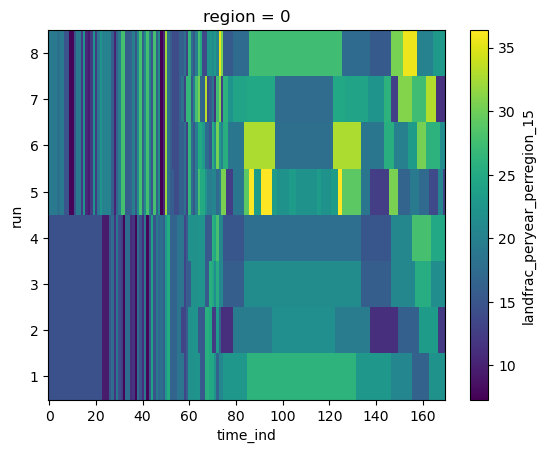

In [146]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_15'].sel(region=0).plot()


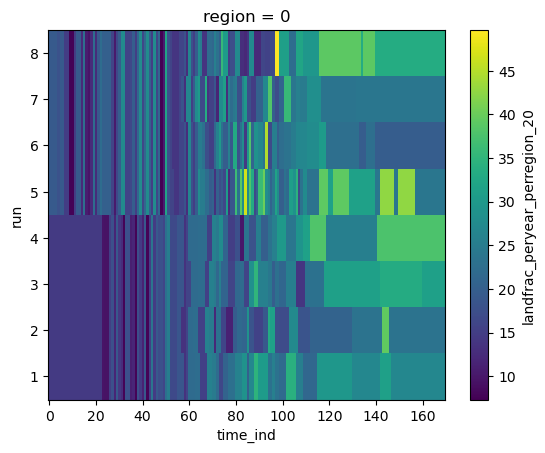

In [147]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_20'].sel(region=0).plot()


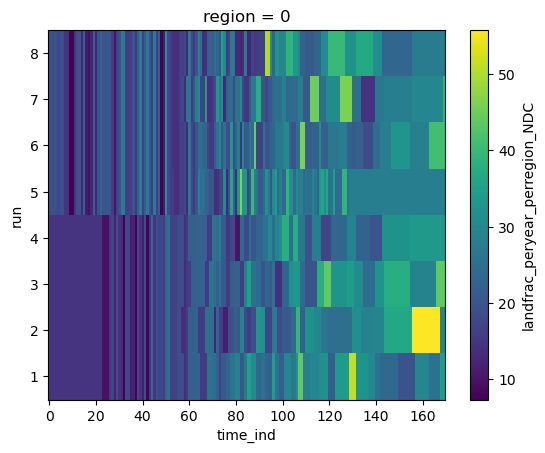

In [148]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_NDC'].sel(region=0).plot()


# 4) Lifetime exposure